# EquiLoan — Master EDA & Model Comparison Notebook
**Project:** Unbiased Loan Approval Prediction System with Demographic Bias Auditing  
**Dataset:** Kaggle Loan Approval Dataset — Ashish Gupta (2022), v2 (real-world noise injected: outliers, extreme values, missingness)  
**Base Paper:** Haque & Hassan (2024) — Bank Loan Prediction Using Machine Learning Techniques  

---

---
## SECTION 0 — Imports & Setup

In [19]:
# ── Core ──────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ── Visualization ─────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
%matplotlib inline
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

# ── ML ────────────────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, ConfusionMatrixDisplay, RocCurveDisplay
)

try:
    from xgboost import XGBClassifier
    XGB_AVAILABLE = True
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, '-m', 'pip', 'install', 'xgboost', '-q'])
    from xgboost import XGBClassifier
    XGB_AVAILABLE = True

RANDOM_STATE = 42
print('All imports successful')

All imports successful


---
## SECTION 1 — Load & Inspect Data

In [20]:
# ── Load ──────────────────────────────────────────────────────────────────
df = pd.read_csv('/content/loan_v2 (1).csv')

print(f'Shape  : {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Memory : {df.memory_usage(deep=True).sum() / 1e6:.1f} MB')
df.head()

Shape  : 148,670 rows × 37 columns
Memory : 185.9 MB


,Unnamed: 0,id,year,loan_limit,gender,approv_in_adv,loan_type,loan_purpose,credit_worthiness,open_credit,...,co-applicant_credit_type,age,submission_of_application,ltv,region,security_type,status,dtir1,high_interest_rate,senior_age
0,126324,151214,2019,cf,Male,nopre,type3,p3,l1,nopc,...,EXP,35-44,to_inst,70.063920,North,direct,0,42.000000,1.0,0.000000
1,13385,38275,2019,cf,Joint,nopre,type2,p4,l1,nopc,...,EXP,>74,not_inst,40.327381,North,direct,0,40.000000,0.0,2.703094
2,98606,123496,2019,cf,Sex Not Available,nopre,type1,p4,l1,nopc,...,CIB,55-64,to_inst,77.388009,south,direct,0,29.000000,1.0,1.000000
3,7184,32074,2019,cf,Female,nopre,type1,p3,l1,nopc,...,CIB,35-44,to_inst,74.280576,North,direct,0,44.000000,1.0,0.000000
4,120745,145635,2019,cf,Male,nopre,type1,p1,l1,nopc,...,CIB,35-44,not_inst,99.107143,North,direct,0,148.317616,0.0,0.000000


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148670 entries, 0 to 148669
Data columns (total 37 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   Unnamed: 0                 148670 non-null  int64  
 1   id                         148670 non-null  int64  
 2   year                       148670 non-null  int64  
 3   loan_limit                 145673 non-null  object 
 4   gender                     148670 non-null  object 
 5   approv_in_adv              147855 non-null  object 
 6   loan_type                  148670 non-null  object 
 7   loan_purpose               148550 non-null  object 
 8   credit_worthiness          148670 non-null  object 
 9   open_credit                148670 non-null  object 
 10  business_or_commercial     148670 non-null  object 
 11  loan_amount                148670 non-null  float64
 12  rate_of_interest           148670 non-null  float64
 13  interest_rate_spread       11

In [22]:
df.describe().T.style.background_gradient(cmap='Blues', subset=['mean','std','50%'])

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,148670.000000,74334.500000,42917.476598,0.000000,37167.250000,74334.500000,111501.750000,148669.000000
id,148670.000000,99224.500000,42917.476598,24890.000000,62057.250000,99224.500000,136391.750000,173559.000000
year,148670.000000,2019.000000,0.000000,2019.000000,2019.000000,2019.000000,2019.000000,2019.000000
loan_amount,148670.000000,452886.207268,1266493.959267,-784681.894634,196500.000000,306500.000000,446500.000000,17880827.799533
rate_of_interest,148670.000000,3.056880,3.552911,-13.145215,1.083761,3.750000,4.375000,39.973486
interest_rate_spread,112387.000000,0.592430,1.453381,-3.638000,0.068400,0.401600,0.820600,16.778990
upfront_charges,109439.000000,6048.180066,25042.889683,-18970.093958,544.390000,2685.090000,5075.000000,299822.523286
term,148629.000000,344.347427,115.508323,-115.519642,360.000000,360.000000,360.000000,1797.780293
property_value,133718.000000,1133831.733265,6193782.997466,-1780588.636876,268000.000000,428000.000000,648000.000000,82484648.969501
income,139624.000000,28550.532474,214851.532369,-33201.374111,3660.000000,5820.000000,8940.000000,2890772.925523


In [23]:
# ── Missing values ────────────────────────────────────────────────────────
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_report = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_report = missing_report[missing_report['Missing Count'] > 0].sort_values('Missing %', ascending=False)

print(f'Columns with missing values: {len(missing_report)}')
missing_report

Columns with missing values: 13


,Missing Count,Missing %
upfront_charges,39231,26.39
interest_rate_spread,36283,24.41
dtir1,23899,16.08
property_value,14952,10.06
ltv,14942,10.05
income,9046,6.08
loan_limit,2997,2.02
approv_in_adv,815,0.55
submission_of_application,180,0.12
age,181,0.12


In [24]:
# ── Unique values per column ──────────────────────────────────────────────
nunique = df.nunique().sort_values()
print('Unique values per column:')
print(nunique)

Unique values per column:
year                              1
loan_limit                        2
approv_in_adv                     2
credit_worthiness                 2
open_credit                       2
business_or_commercial            2
interest_only                     2
neg_ammortization                 2
construction_type                 2
submission_of_application         2
co-applicant_credit_type          2
secured_by                        2
lump_sum_payment                  2
security_type                     2
status                            2
occupancy_type                    3
loan_type                         3
total_units                       4
region                            4
loan_purpose                      4
credit_type                       4
gender                            4
age                               7
dtir1                         12724
property_value                13884
high_interest_rate            14869
senior_age                    14869
te

In [25]:
# ── Target variable distribution ──────────────────────────────────────────

TARGET = 'status'
print('Target column:', TARGET)
print(df[TARGET].value_counts())
print('Class balance (%):')
print((df[TARGET].value_counts(normalize=True) * 100).round(2))

Target column: status
status
0    111273
1     37397
Name: count, dtype: int64
Class balance (%):
status
0    74.85
1    25.15
Name: proportion, dtype: float64


---
## SECTION 2 — Exploratory Data Analysis (EDA)


In [26]:
# ── Working copy for EDA ──────────────────────────────────────────────────
DROP_COLS = [c for c in ['Unnamed: 0', 'id', 'year'] if c in df.columns]
df_eda = df.drop(columns=DROP_COLS).copy()

# BUG FIX: Impute ONLY for visualization purposes — do NOT use this for modelling
num_cols_eda = df_eda.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols_eda = df_eda.select_dtypes(include=['object']).columns.tolist()

for col in num_cols_eda:
    df_eda[col] = df_eda[col].fillna(df_eda[col].median())
for col in cat_cols_eda:
    df_eda[col] = df_eda[col].fillna(df_eda[col].mode()[0])

print(f'EDA dataframe shape: {df_eda.shape}')
print(f'Missing values remaining: {df_eda.isnull().sum().sum()}')

EDA dataframe shape: (148670, 34)
Missing values remaining: 0


In [27]:
# ── 2.1 Missingness Overview ────────────────────────────────────────────# Visual companion to the missing_report table in Section 1 — makes the# imputation strategy (median/mode) easier to justify to a reviewer.miss = df.isnull().sum()miss = miss[miss > 0].sort_values(ascending=True)miss_pct = (miss / len(df) * 100).round(1)fig, ax = plt.subplots(figsize=(9, 6))bars = ax.barh(miss_pct.index, miss_pct.values, color='#EF6C00', edgecolor='white')ax.set_xlabel('Missing (%)')ax.set_title('Missing Data by Column (Before Imputation)', fontweight='bold', fontsize=13)ax.axvline(5, color='gray', linestyle='--', alpha=0.6, linewidth=1)for bar, val in zip(bars, miss_pct.values):    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2, f'{val}%',            va='center', fontsize=9)plt.tight_layout()plt.show()print(f'{len(miss)} columns have missing values, ranging from {miss_pct.min()}% to {miss_pct.max()}%.')print('Strategy: median imputation for numeric columns, mode imputation for categorical columns (Section 3, Step 4).')

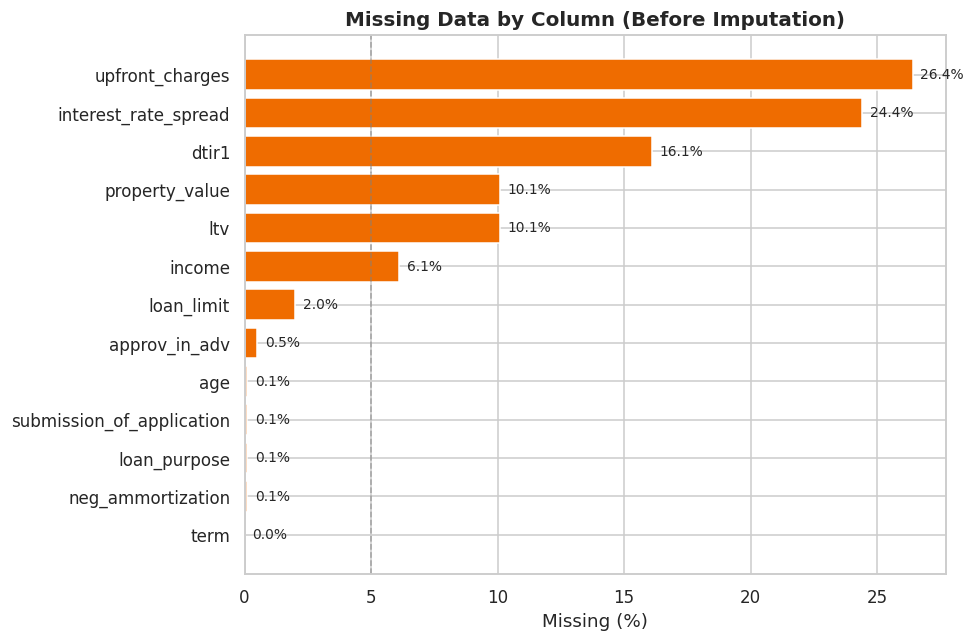

13 columns have missing values, ranging from 0.0% to 26.4%.


In [28]:
# ── Missing Values Graph ──────────────────────────────────────────────────
miss = df.isnull().sum()
miss = miss[miss > 0].sort_values(ascending=True)
miss_pct = (miss / len(df) * 100).round(1)

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(miss_pct.index, miss_pct.values, color='#EF6C00', edgecolor='white')
ax.set_xlabel('Missing (%)')
ax.set_title('Missing Data by Column (Before Imputation)', fontweight='bold', fontsize=13)
ax.axvline(5, color='gray', linestyle='--', alpha=0.6, linewidth=1)
for bar, val in zip(bars, miss_pct.values):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2, f'{val}%',
            va='center', fontsize=9)
plt.tight_layout()
plt.show()

print(f'{len(miss)} columns have missing values, ranging from {miss_pct.min()}% to {miss_pct.max()}%.')

Outlier counts (IQR method):
  income: 11,679 outliers (7.9%)
  loan_amount: 4,752 outliers (3.2%)
  property_value: 10,080 outliers (6.8%)
  rate_of_interest: 2,781 outliers (1.9%)
  ltv: 9,590 outliers (6.5%)
  dtir1: 9,179 outliers (6.2%)


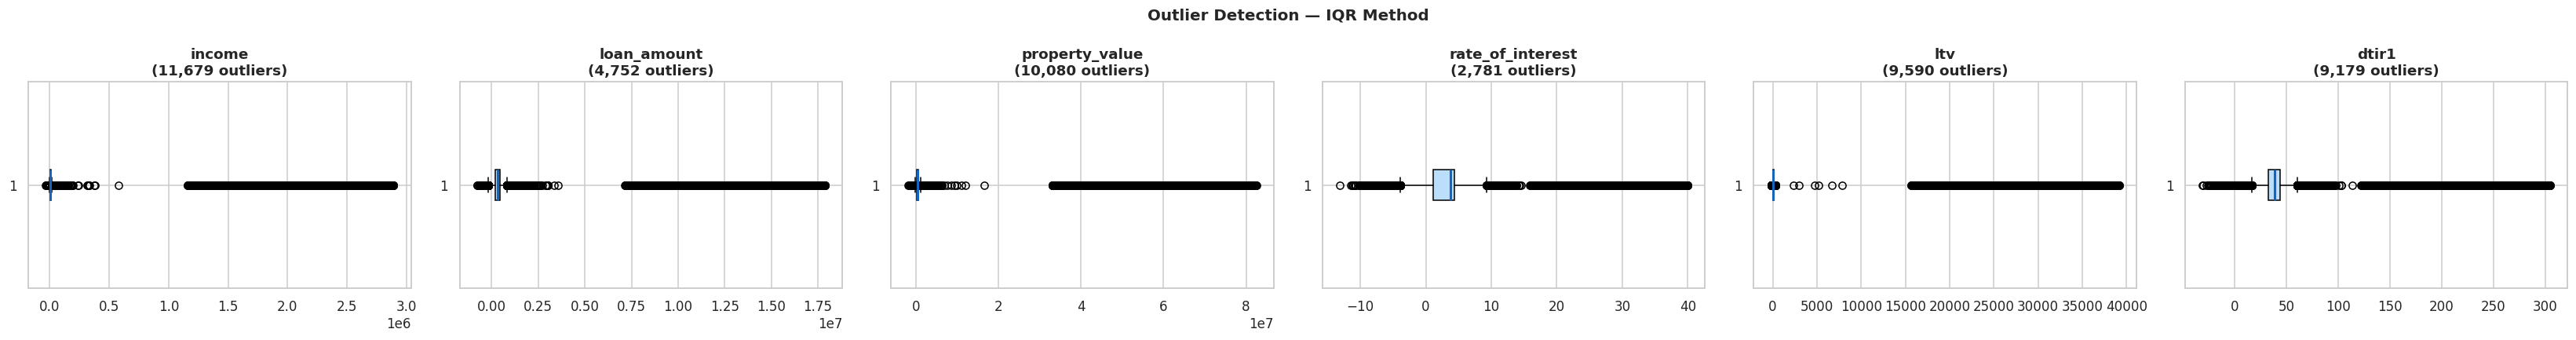

In [29]:
# ── Outlier Detection Graph (Box Plots, IQR method) ───────────────────────
TARGET = 'status'
if 'df_eda' not in dir():
    _DROP = [c for c in ['Unnamed: 0', 'id', 'year'] if c in df.columns]
    df_eda = df.drop(columns=_DROP).copy()
    for _col in df_eda.select_dtypes(include=['int64', 'float64']).columns:
        df_eda[_col] = df_eda[_col].fillna(df_eda[_col].median())
    for _col in df_eda.select_dtypes(include=['object']).columns:
        df_eda[_col] = df_eda[_col].fillna(df_eda[_col].mode()[0])

iqr_cols = [c for c in ['income', 'loan_amount', 'property_value', 'rate_of_interest', 'ltv', 'dtir1']
            if c in df_eda.columns]

fig, axes = plt.subplots(1, len(iqr_cols), figsize=(5 * len(iqr_cols), 4))
if len(iqr_cols) == 1:
    axes = [axes]

print('Outlier counts (IQR method):')
for ax, col in zip(axes, iqr_cols):
    ax.boxplot(df_eda[col].dropna(), vert=False, patch_artist=True,
               boxprops=dict(facecolor='#BBDEFB'),
               medianprops=dict(color='#1565C0', linewidth=2))
    Q1 = df_eda[col].quantile(0.25)
    Q3 = df_eda[col].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((df_eda[col] < Q1 - 1.5*IQR) | (df_eda[col] > Q3 + 1.5*IQR)).sum()
    ax.set_title(f'{col}\n({n_out:,} outliers)', fontweight='bold')
    print(f'  {col}: {n_out:,} outliers ({n_out/len(df_eda)*100:.1f}%)')

plt.suptitle('Outlier Detection — IQR Method', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

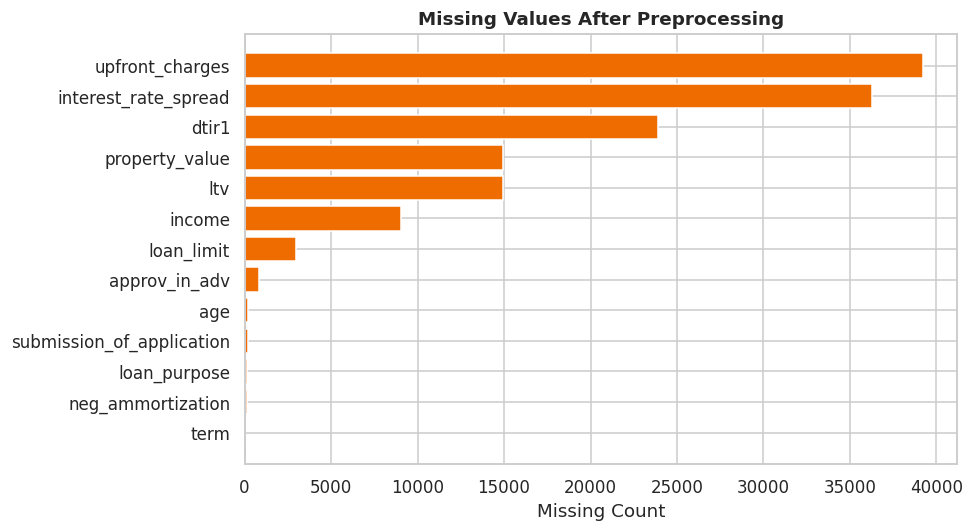

⚠️ 13 columns still have missing values.
✅ No duplicate rows remain.


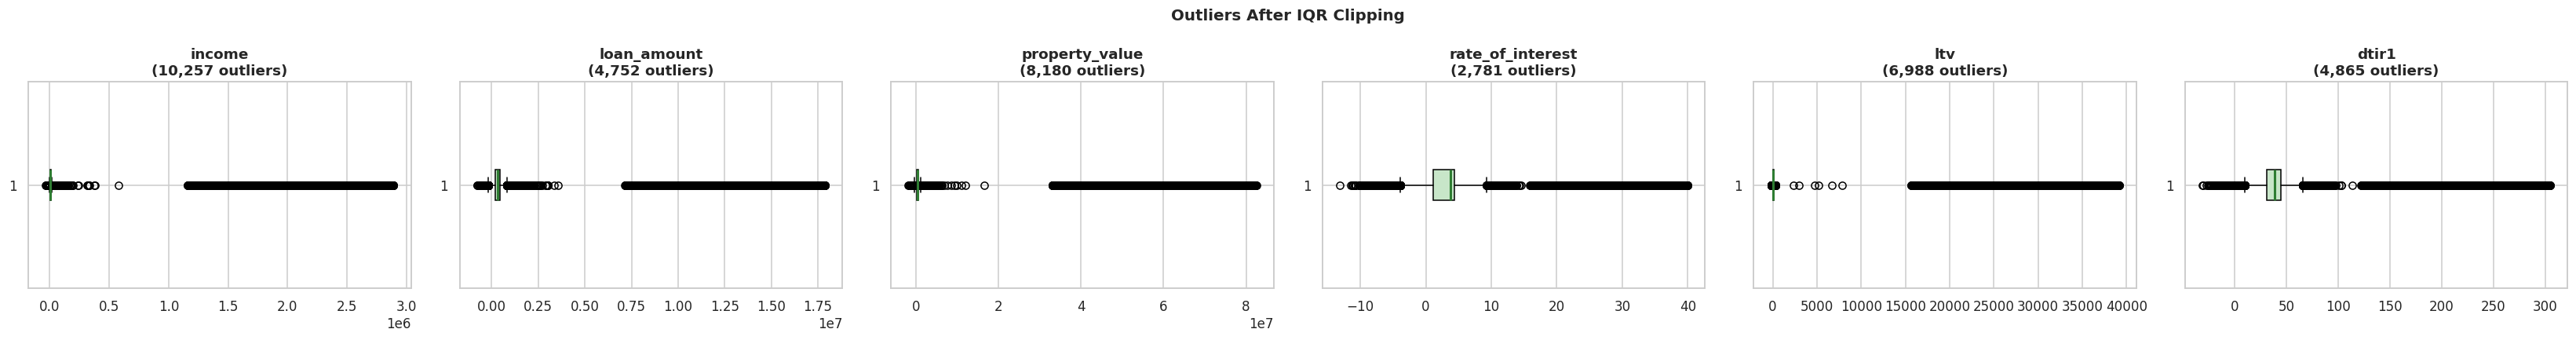

⚠️ Some outliers remain beyond the fences (values were clipped, not removed, so a few can sit exactly on the boundary).


In [30]:
# ── Post-Preprocessing Check: Missing / Duplicates / Clipped Outliers ─────
TARGET = 'status'
if 'df_clean' not in dir():
    raise NameError("df_clean not found — run Section 3 (Preprocessing Pipeline) first.")

# 1) Missing values remaining
miss_after = df_clean.isnull().sum()
miss_after = miss_after[miss_after > 0].sort_values(ascending=True)

if len(miss_after) > 0:
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.barh(miss_after.index, miss_after.values, color='#EF6C00', edgecolor='white')
    ax.set_xlabel('Missing Count')
    ax.set_title('Missing Values After Preprocessing', fontweight='bold')
    plt.tight_layout()
    plt.show()
    print(f'⚠️ {len(miss_after)} columns still have missing values.')
else:
    print('✅ No missing values remain after imputation.')

# 2) Duplicate rows
dup_count = df_clean.duplicated().sum()
if dup_count > 0:
    fig, ax = plt.subplots(figsize=(4, 4))
    ax.bar(['Unique', 'Duplicate'], [len(df_clean) - dup_count, dup_count],
           color=['#90CAF9', '#EF9A9A'], edgecolor='white')
    ax.set_title('Duplicate Rows After Cleaning', fontweight='bold')
    for i, v in enumerate([len(df_clean) - dup_count, dup_count]):
        ax.text(i, v, f'{v:,}', ha='center', va='bottom', fontsize=9)
    plt.tight_layout()
    plt.show()
    print(f'⚠️ {dup_count:,} duplicate rows remain.')
else:
    print('✅ No duplicate rows remain.')

# 3) Outliers after IQR clipping
iqr_cols = [c for c in ['income', 'loan_amount', 'property_value', 'rate_of_interest', 'ltv', 'dtir1']
            if c in df_clean.columns]

remaining_outliers = {}
for col in iqr_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((df_clean[col] < Q1 - 1.5*IQR) | (df_clean[col] > Q3 + 1.5*IQR)).sum()
    remaining_outliers[col] = n_out

if any(v > 0 for v in remaining_outliers.values()):
    fig, axes = plt.subplots(1, len(iqr_cols), figsize=(5 * len(iqr_cols), 4))
    if len(iqr_cols) == 1:
        axes = [axes]
    for ax, col in zip(axes, iqr_cols):
        ax.boxplot(df_clean[col].dropna(), vert=False, patch_artist=True,
                   boxprops=dict(facecolor='#C8E6C9'),
                   medianprops=dict(color='#2E7D32', linewidth=2))
        ax.set_title(f'{col}\n({remaining_outliers[col]:,} outliers)', fontweight='bold')
    plt.suptitle('Outliers After IQR Clipping', fontweight='bold', fontsize=13)
    plt.tight_layout()
    plt.show()
    print('⚠️ Some outliers remain beyond the fences (values were clipped, not removed, so a few can sit exactly on the boundary).')
else:
    print('✅ No outliers remain beyond the IQR fences in the clipped columns.')

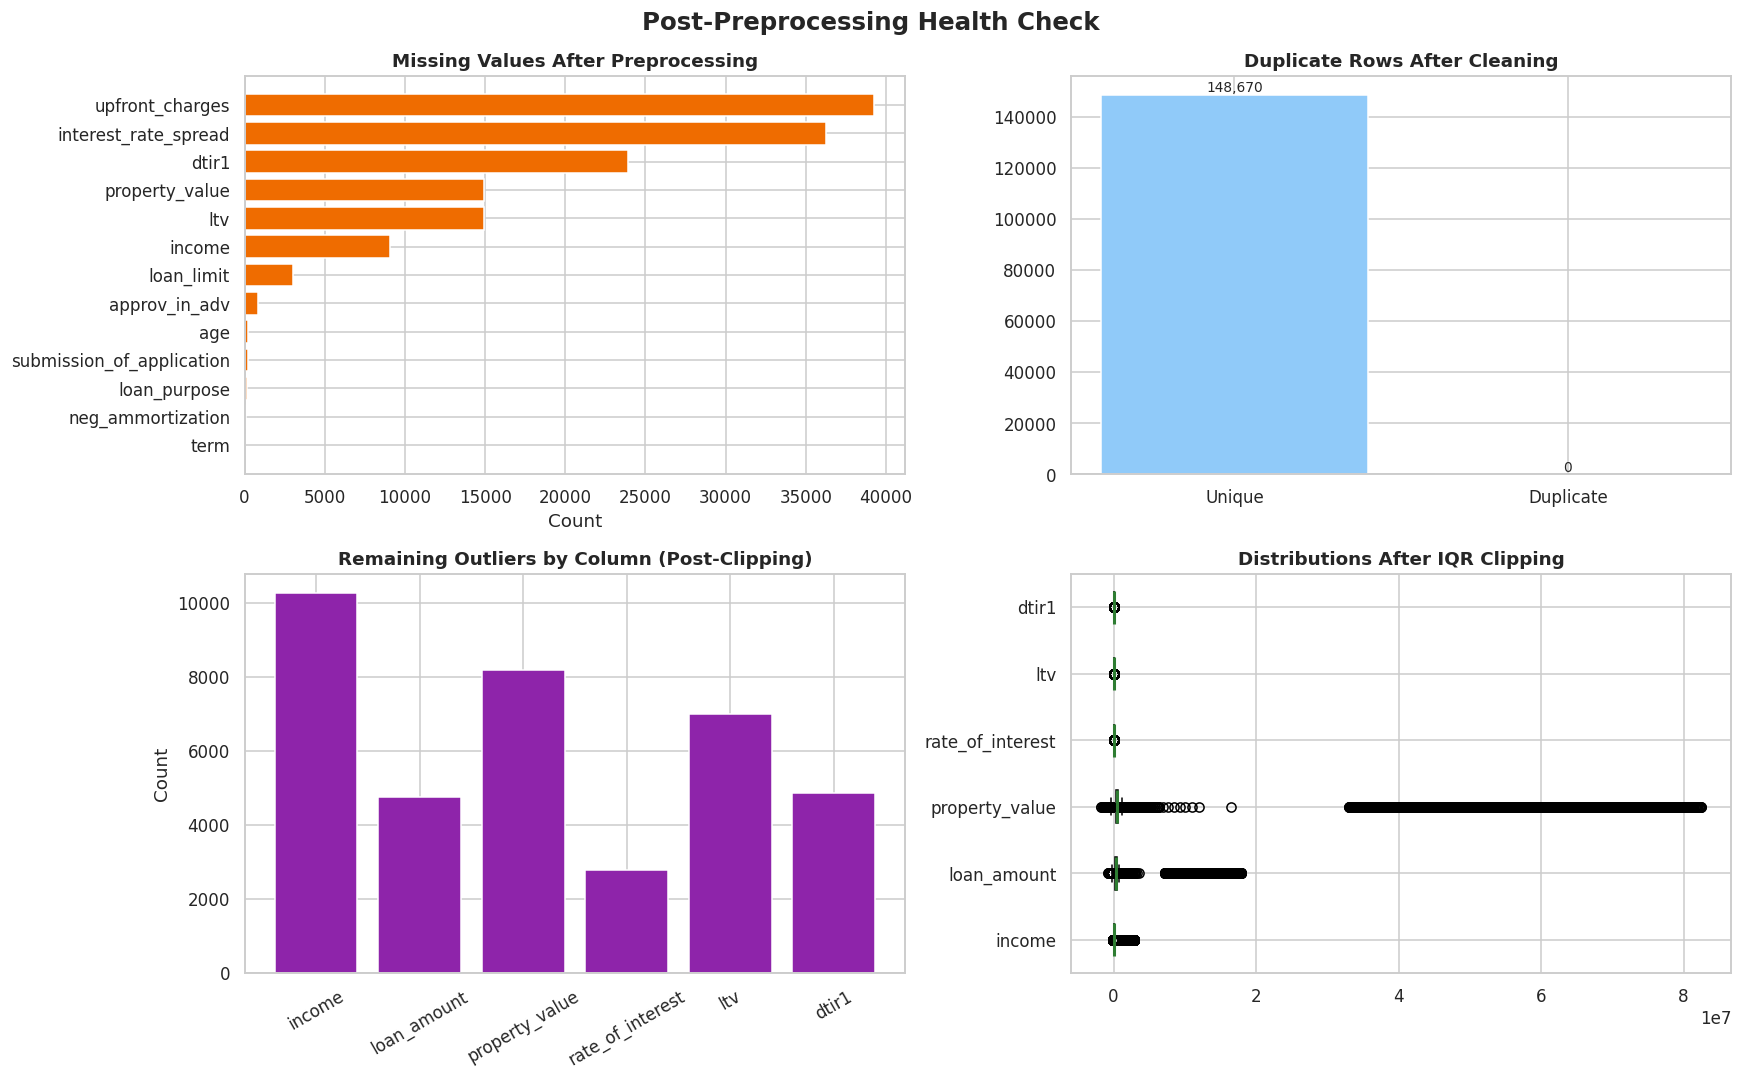

In [31]:
# ── Post-Preprocessing Health Check — Graphical Summary ───────────────────
TARGET = 'status'
if 'df_clean' not in dir():
    raise NameError("df_clean not found — run Section 3 (Preprocessing Pipeline) first.")

iqr_cols = [c for c in ['income', 'loan_amount', 'property_value', 'rate_of_interest', 'ltv', 'dtir1']
            if c in df_clean.columns]

# Compute all three metrics
miss_after = df_clean.isnull().sum()
miss_after = miss_after[miss_after > 0].sort_values(ascending=True)

dup_count = df_clean.duplicated().sum()
clean_count = len(df_clean) - dup_count

outlier_counts = {}
for col in iqr_cols:
    Q1, Q3 = df_clean[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    outlier_counts[col] = ((df_clean[col] < Q1 - 1.5*IQR) | (df_clean[col] > Q3 + 1.5*IQR)).sum()

fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(2, 2)

# 1) Missing values
ax1 = fig.add_subplot(gs[0, 0])
if len(miss_after) > 0:
    ax1.barh(miss_after.index, miss_after.values, color='#EF6C00', edgecolor='white')
else:
    ax1.barh(['No missing values'], [0], color='#66BB6A')
ax1.set_title('Missing Values After Preprocessing', fontweight='bold')
ax1.set_xlabel('Count')

# 2) Duplicates
ax2 = fig.add_subplot(gs[0, 1])
ax2.bar(['Unique', 'Duplicate'], [clean_count, dup_count],
        color=['#90CAF9', '#EF9A9A'], edgecolor='white')
ax2.set_title('Duplicate Rows After Cleaning', fontweight='bold')
for i, v in enumerate([clean_count, dup_count]):
    ax2.text(i, v, f'{v:,}', ha='center', va='bottom', fontsize=9)

# 3) Outlier counts bar
ax3 = fig.add_subplot(gs[1, 0])
ax3.bar(list(outlier_counts.keys()), list(outlier_counts.values()), color='#8E24AA', edgecolor='white')
ax3.set_title('Remaining Outliers by Column (Post-Clipping)', fontweight='bold')
ax3.tick_params(axis='x', rotation=30)
ax3.set_ylabel('Count')

# 4) Box plots after clipping
ax4 = fig.add_subplot(gs[1, 1])
ax4.boxplot([df_clean[col].dropna() for col in iqr_cols], vert=False, patch_artist=True,
            boxprops=dict(facecolor='#C8E6C9'), medianprops=dict(color='#2E7D32', linewidth=2),
            labels=iqr_cols)
ax4.set_title('Distributions After IQR Clipping', fontweight='bold')

plt.suptitle('Post-Preprocessing Health Check', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

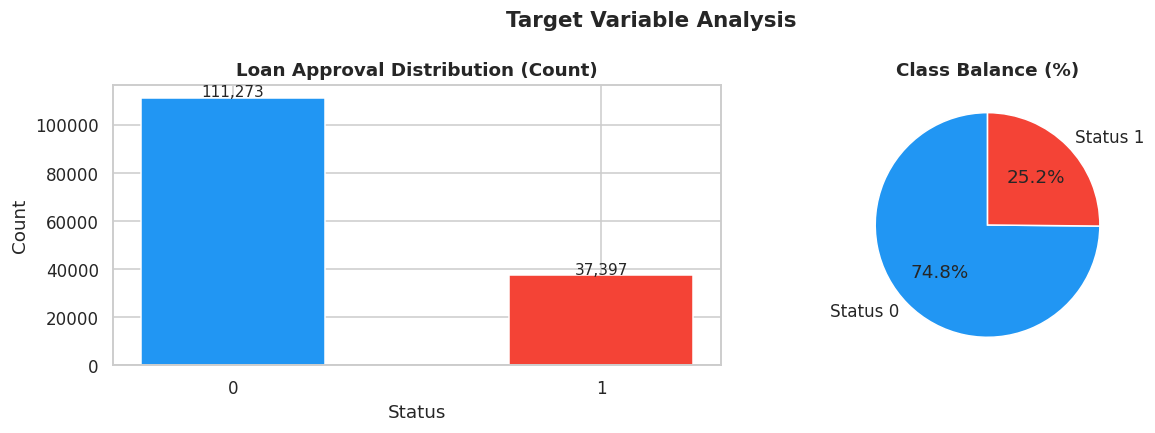

⚠️  Class imbalance detected — accuracy alone is misleading. Use F1 + ROC-AUC.


In [32]:
# ── 2.1 Target Distribution ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

vc = df_eda[TARGET].value_counts()
axes[0].bar(vc.index.astype(str), vc.values, color=['#2196F3','#F44336'], edgecolor='white', width=0.5)
axes[0].set_title('Loan Approval Distribution (Count)', fontweight='bold')
axes[0].set_xlabel('Status')
axes[0].set_ylabel('Count')
for i, v in enumerate(vc.values):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontsize=10)

axes[1].pie(vc.values, labels=[f'Status {i}' for i in vc.index],
            autopct='%1.1f%%', colors=['#2196F3','#F44336'],
            startangle=90, wedgeprops=dict(edgecolor='white'))
axes[1].set_title('Class Balance (%)', fontweight='bold')

plt.suptitle('Target Variable Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('⚠️  Class imbalance detected — accuracy alone is misleading. Use F1 + ROC-AUC.')

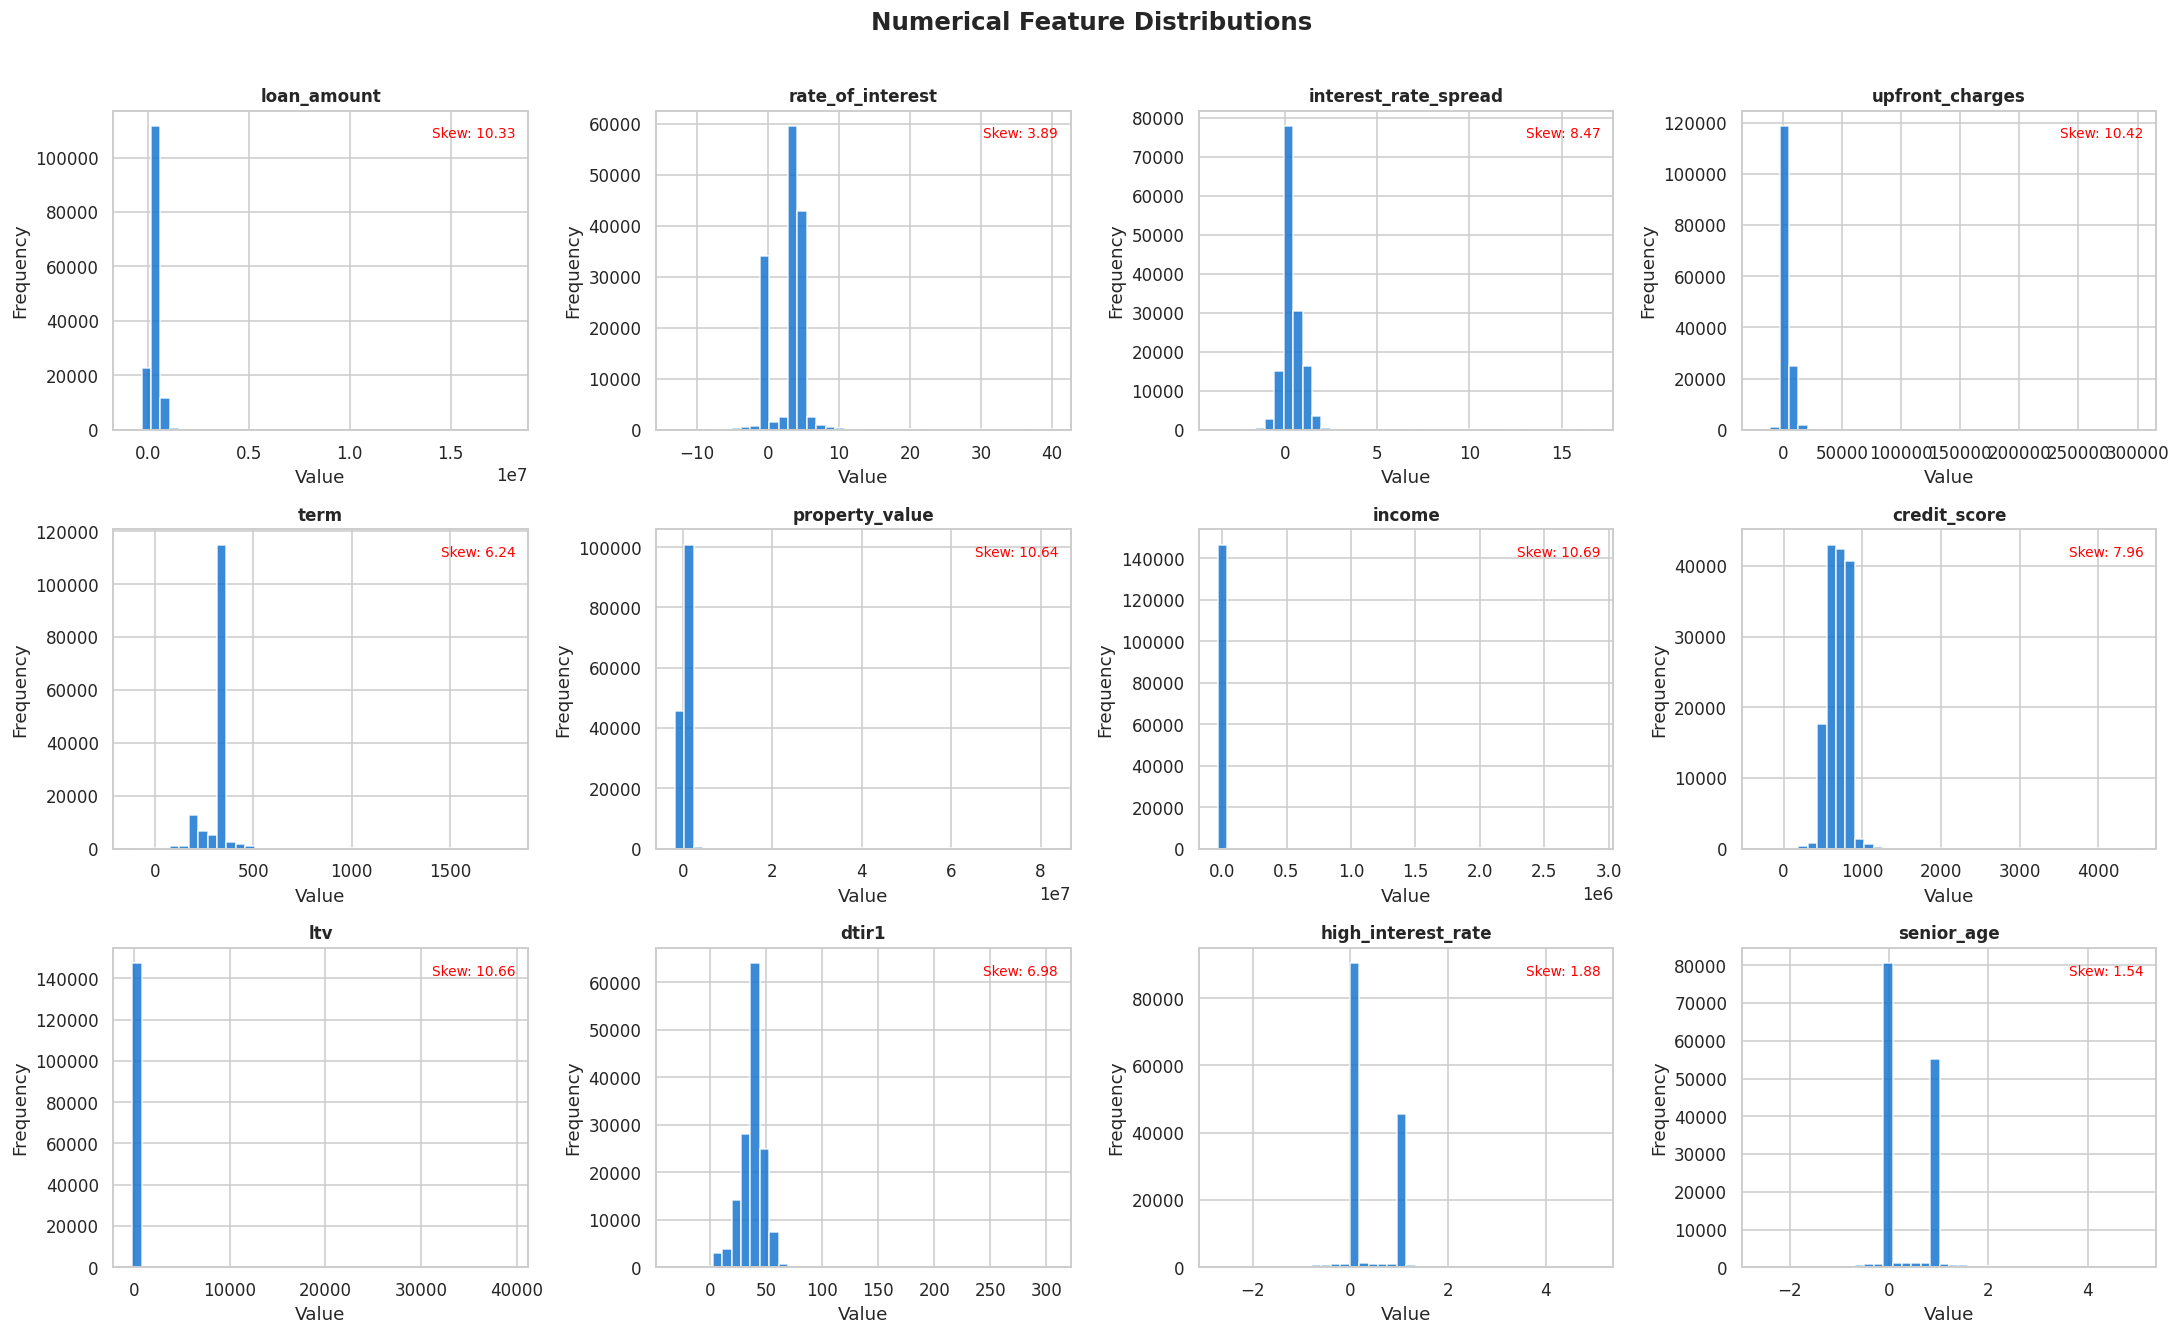

In [33]:
# ── 2.2 Numerical Feature Distributions ──────────────────────────────────
num_features = [c for c in num_cols_eda if c != TARGET]

n_cols = 4
n_rows = (len(num_features) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(num_features):
    axes[i].hist(df_eda[col].dropna(), bins=40, color='#1976D2', edgecolor='white', alpha=0.85)
    axes[i].set_title(col, fontweight='bold', fontsize=11)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')
    skew = df_eda[col].skew()
    axes[i].text(0.97, 0.95, f'Skew: {skew:.2f}', transform=axes[i].transAxes,
                 ha='right', va='top', fontsize=9,
                 color='red' if abs(skew) > 1 else 'green')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numerical Feature Distributions', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

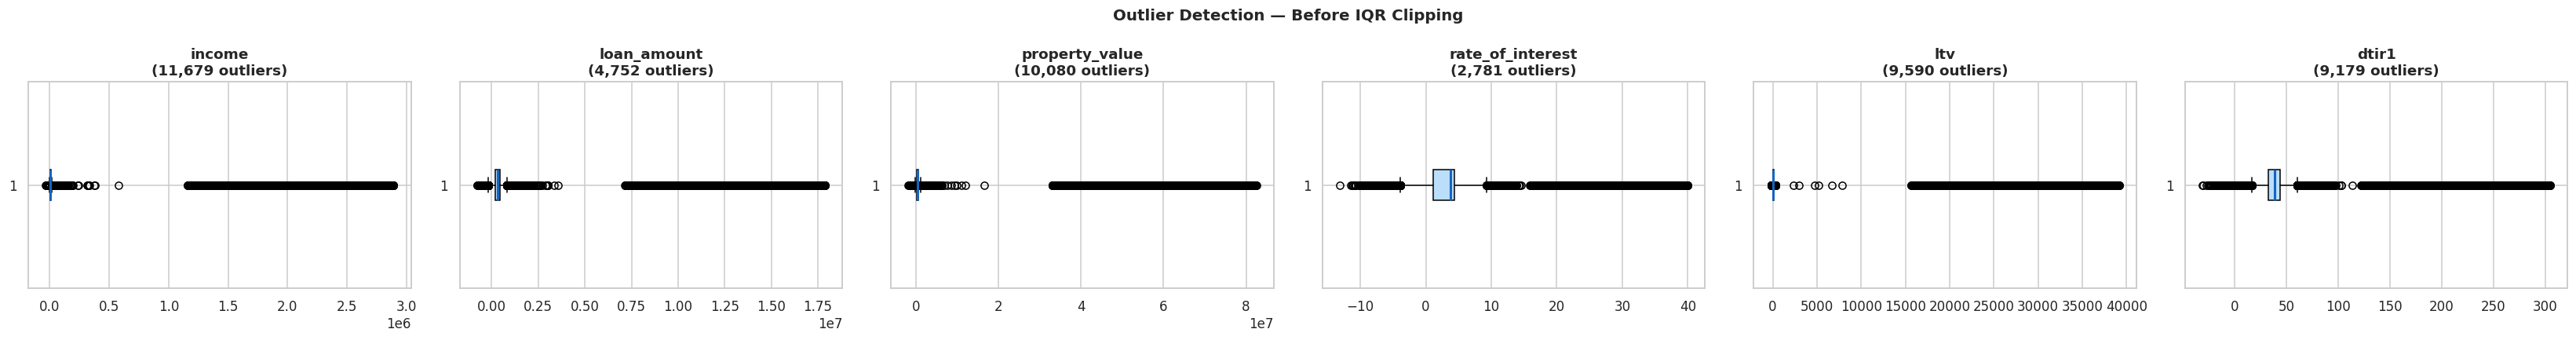

Outlier counts (IQR method):
  income: 11,679 outliers (7.9%)
  loan_amount: 4,752 outliers (3.2%)
  property_value: 10,080 outliers (6.8%)
  rate_of_interest: 2,781 outliers (1.9%)
  ltv: 9,590 outliers (6.5%)
  dtir1: 9,179 outliers (6.2%)


In [34]:
# ── 2.3 Outlier Detection — Box Plots ────────────────────────────────────
# Only apply IQR to columns where it makes sense
iqr_cols = [c for c in ['income', 'loan_amount', 'property_value', 'rate_of_interest', 'ltv', 'dtir1']
            if c in df_eda.columns]

if iqr_cols:
    fig, axes = plt.subplots(1, len(iqr_cols), figsize=(5 * len(iqr_cols), 4))
    if len(iqr_cols) == 1:
        axes = [axes]
    for ax, col in zip(axes, iqr_cols):
        ax.boxplot(df_eda[col].dropna(), vert=False, patch_artist=True,
                   boxprops=dict(facecolor='#BBDEFB'),
                   medianprops=dict(color='#1565C0', linewidth=2))
        Q1 = df_eda[col].quantile(0.25)
        Q3 = df_eda[col].quantile(0.75)
        IQR = Q3 - Q1
        outliers = ((df_eda[col] < Q1 - 1.5*IQR) | (df_eda[col] > Q3 + 1.5*IQR)).sum()
        ax.set_title(f'{col}\n({outliers:,} outliers)', fontweight='bold')
    plt.suptitle('Outlier Detection — Before IQR Clipping', fontweight='bold', fontsize=13)
    plt.tight_layout()
    plt.show()

# Print outlier counts
print('Outlier counts (IQR method):')
for col in iqr_cols:
    Q1 = df_eda[col].quantile(0.25)
    Q3 = df_eda[col].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((df_eda[col] < Q1 - 1.5*IQR) | (df_eda[col] > Q3 + 1.5*IQR)).sum()
    print(f'  {col}: {n_out:,} outliers ({n_out/len(df_eda)*100:.1f}%)')

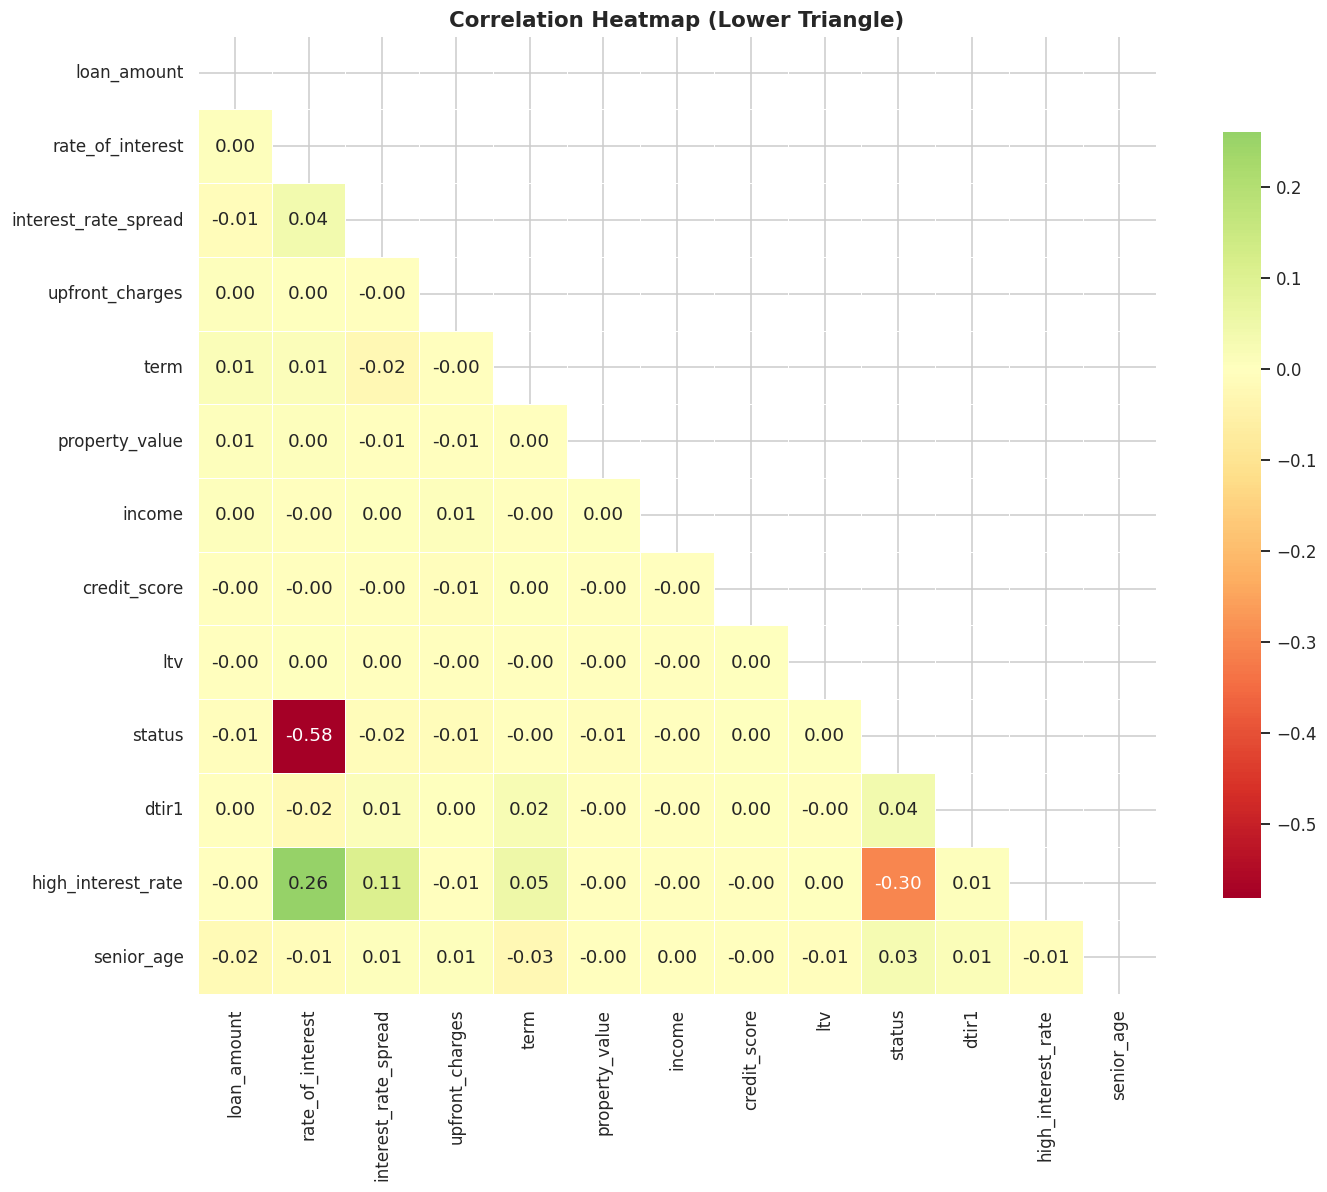

In [35]:
# ── 2.4 Correlation Heatmap ───────────────────────────────────────────────
plt.figure(figsize=(14, 11))
num_only = df_eda.select_dtypes(include=['int64', 'float64'])
corr = num_only.corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr,
    mask=mask,
    cmap='RdYlGn',
    center=0,
    annot=len(corr) <= 20,
    fmt='.2f',
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)
plt.title('Correlation Heatmap (Lower Triangle)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [36]:
# ── Defensive guard: rebuild what this cell needs if the runtime was
# restarted or cells were run out of order (avoids KeyError: 'status') ──
TARGET = 'status'
if 'df_eda' not in dir():
    _DROP = [c for c in ['Unnamed: 0', 'id', 'year'] if c in df.columns]
    df_eda = df.drop(columns=_DROP).copy()
    for _col in df_eda.select_dtypes(include=['int64', 'float64']).columns:
        df_eda[_col] = df_eda[_col].fillna(df_eda[_col].median())
    for _col in df_eda.select_dtypes(include=['object']).columns:
        df_eda[_col] = df_eda[_col].fillna(df_eda[_col].mode()[0])

# ── 2.4b Bivariate Check — Why does rate_of_interest dominate the heatmap? ─# The correlation heatmap shows rate_of_interest at -0.58 with status, while every# other feature sits near 0. That gap is large enough to investigate before modelling —# it is very likely the reason Logistic Regression alone reaches ~96% accuracy in# Section 4, and it is worth flagging explicitly rather than letting it pass silently.sample = df_eda.sample(n=min(6000, len(df_eda)), random_state=RANDOM_STATE)fig, axes = plt.subplots(1, 2, figsize=(13, 5))for status_val, color, label in zip([0, 1], ['#90CAF9', '#EF9A9A'], ['Approved (0)', 'Rejected (1)']):    subset = sample[sample[TARGET] == status_val]    axes[0].scatter(subset['rate_of_interest'], subset['credit_score'],                     s=10, alpha=0.35, color=color, label=label)axes[0].set_xlabel('Rate of Interest')axes[0].set_ylabel('Credit Score')axes[0].set_title('Rate of Interest vs Credit Score, by Status', fontweight='bold')axes[0].legend()sns.kdeplot(data=sample, x='rate_of_interest', hue=sample[TARGET].map({0: 'Approved', 1: 'Rejected'}),            fill=True, alpha=0.4, ax=axes[1], palette=['#90CAF9', '#EF9A9A'])axes[1].set_title('Rate of Interest Distribution by Status', fontweight='bold')axes[1].set_xlabel('Rate of Interest')plt.suptitle('Investigating the Dominant Correlation (rate_of_interest vs status = -0.58)', fontsize=13, fontweight='bold')plt.tight_layout()plt.show()print('⚠️  rate_of_interest visibly separates the two classes almost on its own.')print('    This should be reported as a modelling caveat: Logistic Regression\'s strong')print('    performance is likely driven heavily by this one feature, not by the full feature set.')

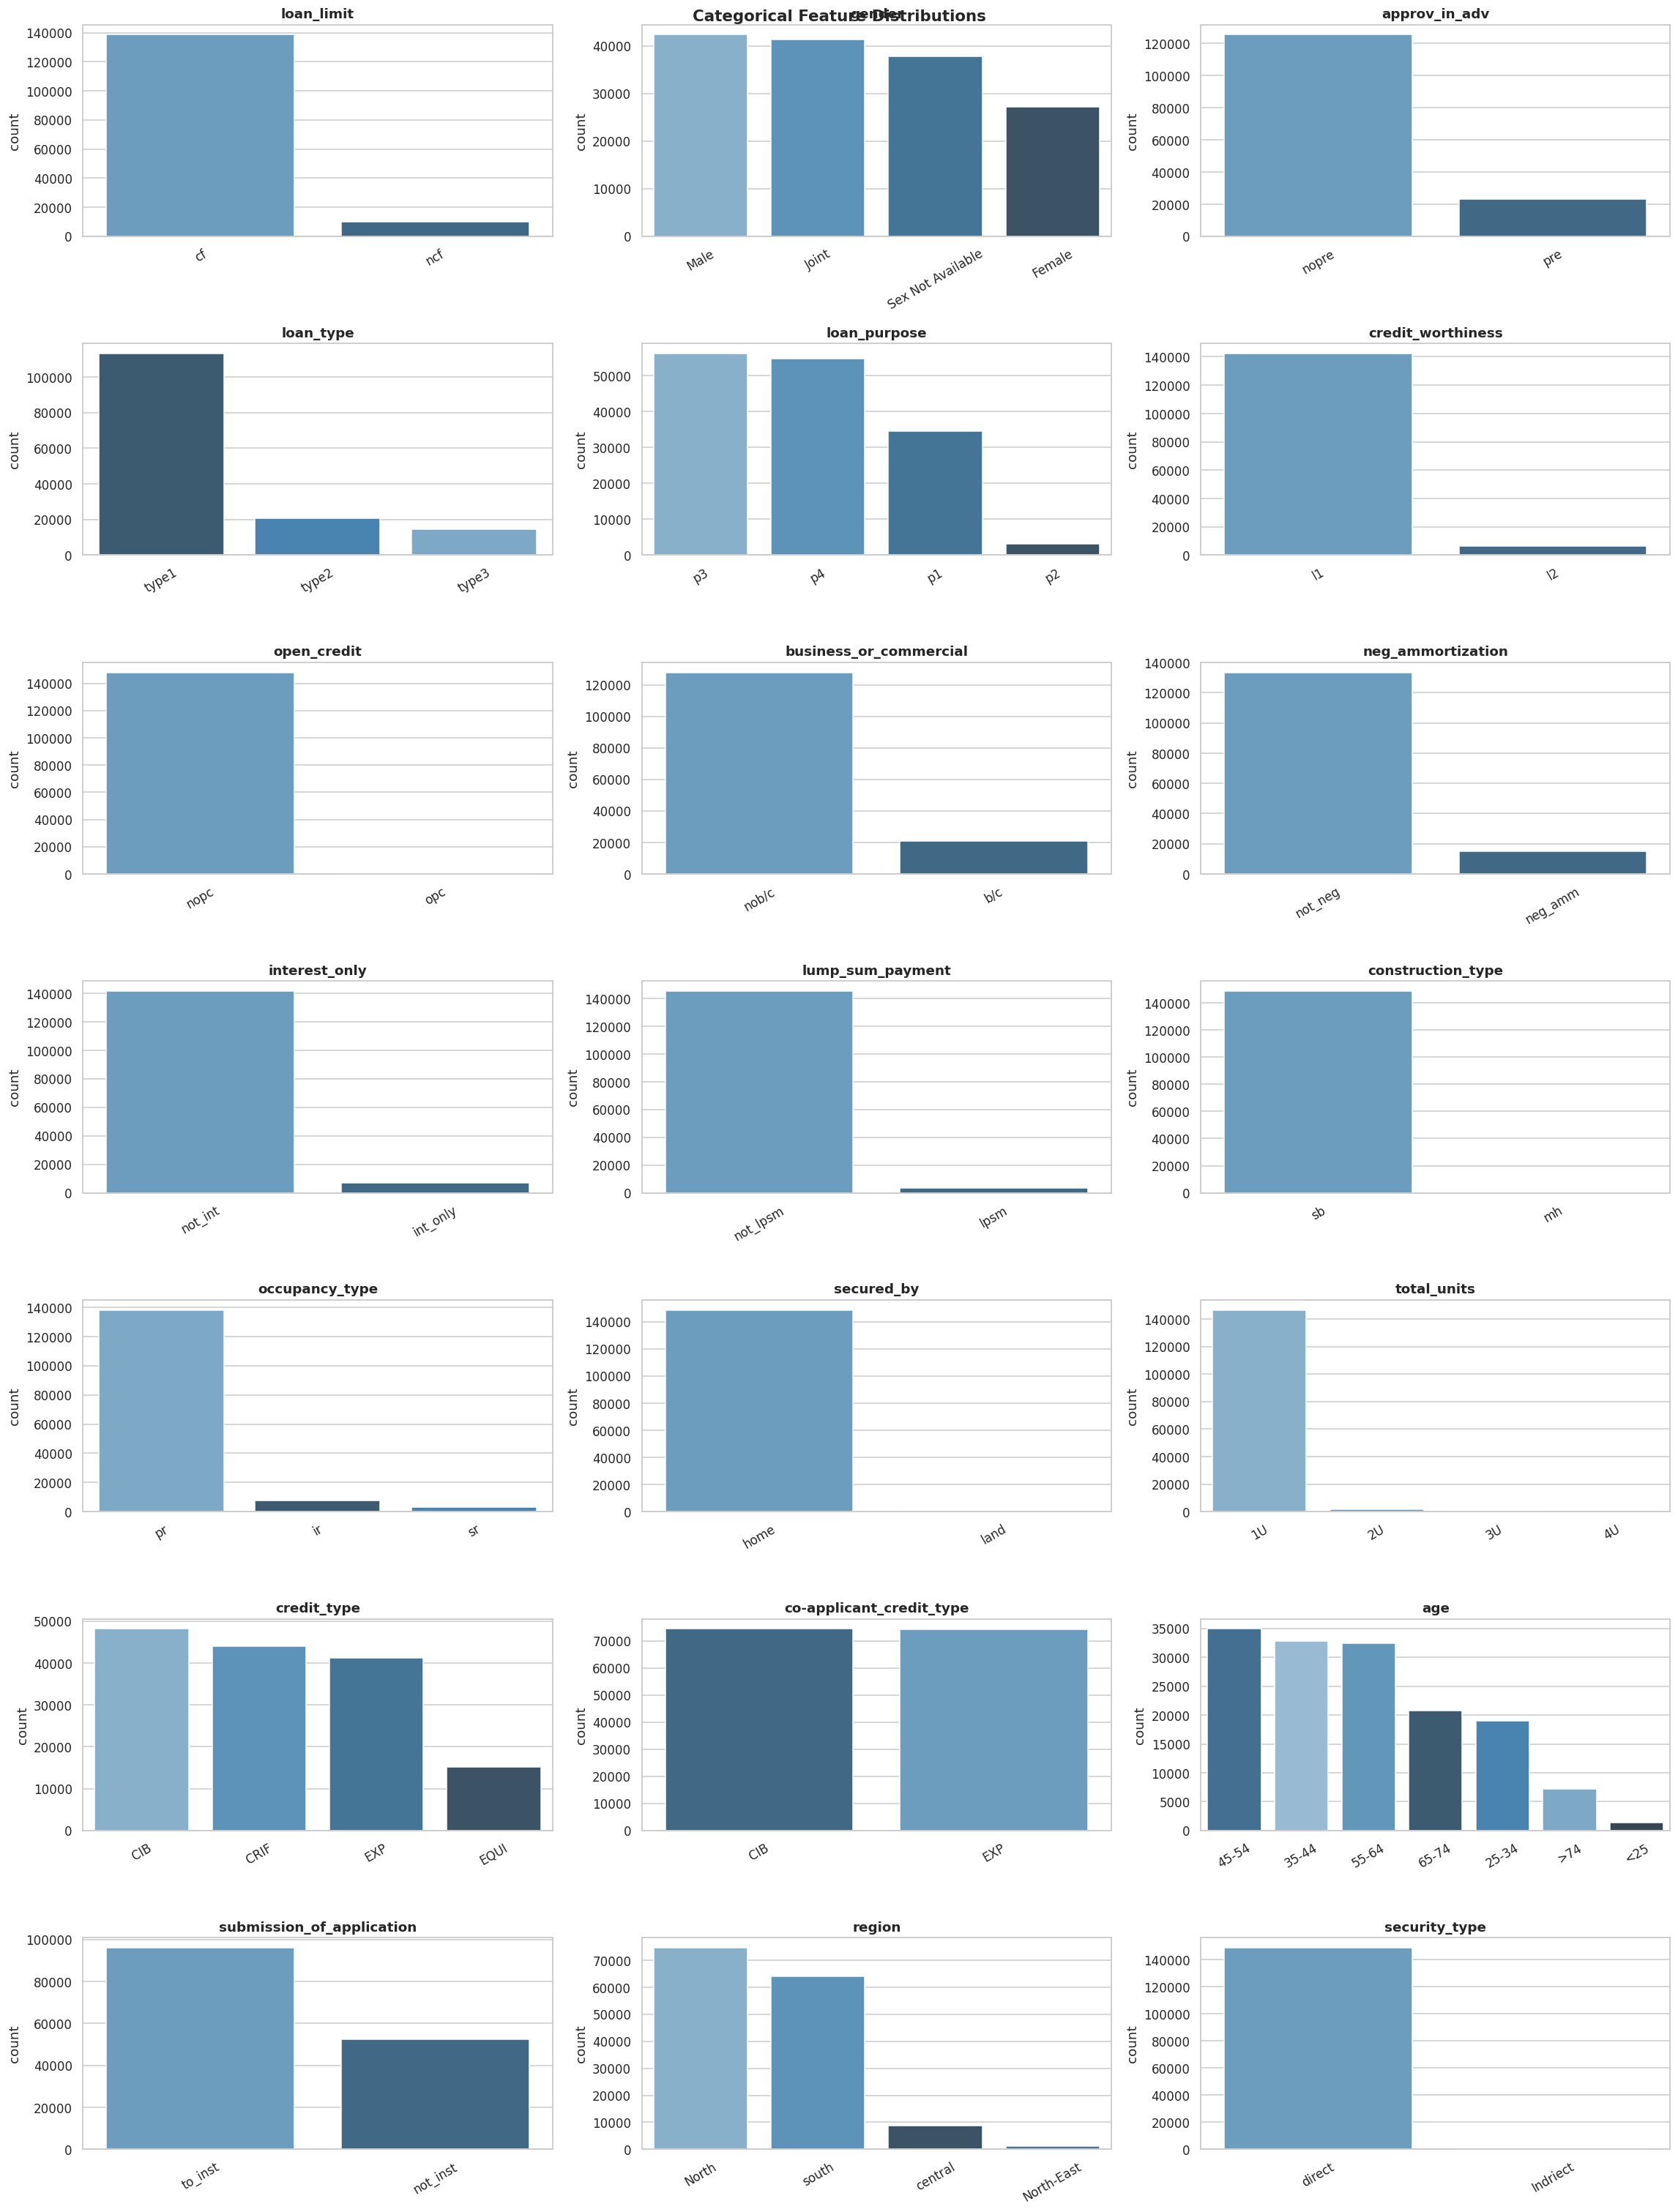

In [37]:
# ── 2.5 Categorical Feature Distributions ─────────────────────────────────
cat_features = [c for c in cat_cols_eda if c != TARGET]

if cat_features:
    n_cols_cat = min(3, len(cat_features))
    n_rows_cat = (len(cat_features) + n_cols_cat - 1) // n_cols_cat
    fig, axes = plt.subplots(n_rows_cat, n_cols_cat, figsize=(7 * n_cols_cat, 4 * n_rows_cat))
    axes = np.array(axes).flatten()
    for i, col in enumerate(cat_features):
        order = df_eda[col].value_counts().index
        sns.countplot(x=col, data=df_eda, order=order, ax=axes[i], hue=col, palette='Blues_d', legend=False)
        axes[i].set_title(col, fontweight='bold')
        axes[i].set_xlabel('')
        axes[i].tick_params(axis='x', rotation=30)
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    plt.suptitle('Categorical Feature Distributions', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

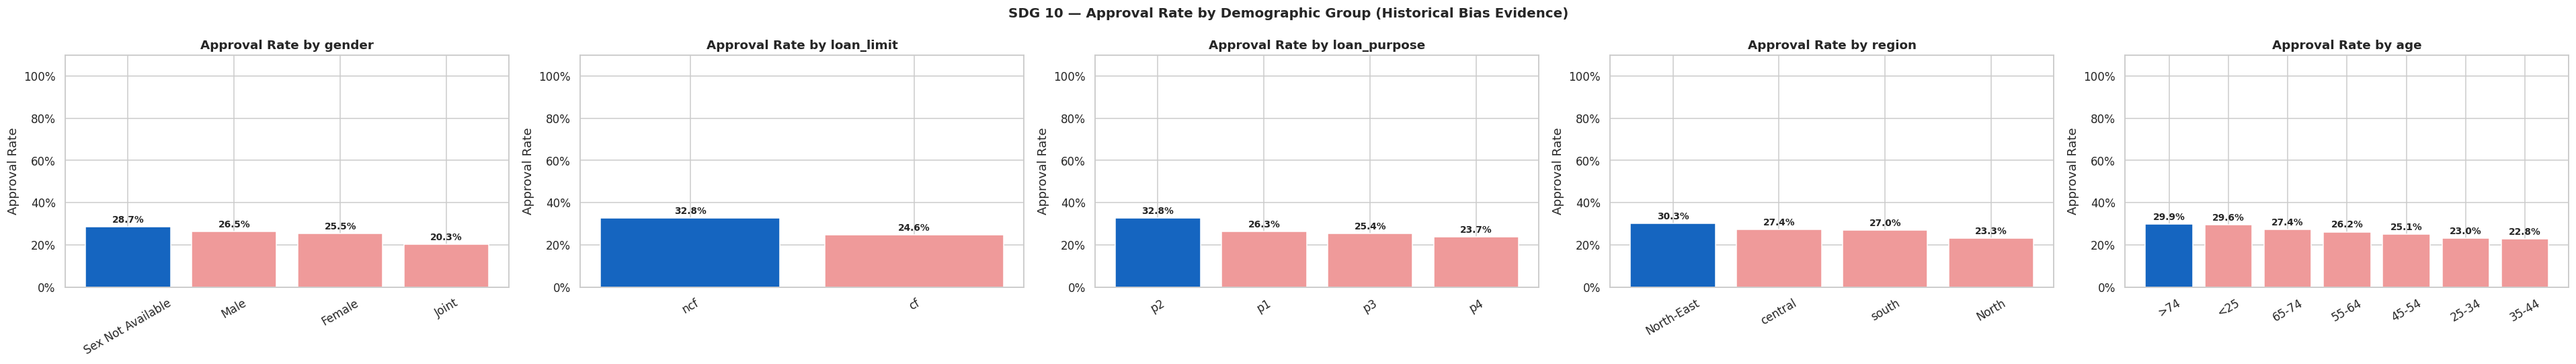

In [38]:
# ── 2.6 SDG 10 Fairness — Approval Rate by Demographic Group ──────────────
# These are the fairness-sensitive features for our SDG 10 audit
fairness_cols = [c for c in ['gender', 'loan_limit', 'loan_purpose', 'region', 'age']
                 if c in df_eda.columns]

if fairness_cols and TARGET in df_eda.columns:
    n = len(fairness_cols)
    fig, axes = plt.subplots(1, n, figsize=(7 * n, 5))
    if n == 1: axes = [axes]
    for ax, col in zip(axes, fairness_cols):
        approval_rate = df_eda.groupby(col)[TARGET].mean().sort_values(ascending=False)
        bars = ax.bar(approval_rate.index.astype(str), approval_rate.values,
                      color=['#1565C0' if v == approval_rate.max() else '#EF9A9A'
                             for v in approval_rate.values],
                      edgecolor='white')
        ax.set_title(f'Approval Rate by {col}', fontweight='bold')
        ax.set_ylabel('Approval Rate')
        ax.set_ylim(0, 1.1)
        ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
        ax.tick_params(axis='x', rotation=30)
        for bar, val in zip(bars, approval_rate.values):
            ax.text(bar.get_x() + bar.get_width()/2, val + 0.02,
                    f'{val:.1%}', ha='center', fontsize=9, fontweight='bold')
    plt.suptitle('SDG 10 — Approval Rate by Demographic Group (Historical Bias Evidence)',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [39]:
# ── Defensive guard: rebuild what this cell needs if the runtime was
# restarted or cells were run out of order (avoids KeyError: 'status') ──
TARGET = 'status'
if 'df_eda' not in dir():
    _DROP = [c for c in ['Unnamed: 0', 'id', 'year'] if c in df.columns]
    df_eda = df.drop(columns=_DROP).copy()
    for _col in df_eda.select_dtypes(include=['int64', 'float64']).columns:
        df_eda[_col] = df_eda[_col].fillna(df_eda[_col].median())
    for _col in df_eda.select_dtypes(include=['object']).columns:
        df_eda[_col] = df_eda[_col].fillna(df_eda[_col].mode()[0])

# ── 2.7 Key Financial Features vs Loan Status (view clipped at 1st/99th pct) ─# NOTE: plotting raw income/loan_amount/property_value makes the boxes invisible —# a handful of extreme outliers stretch the y-axis so far that the actual# interquartile range collapses to a flat line (see original attempt). This clip# is for VISUALIZATION ONLY; modelling uses the IQR-clipped df_clean in Section 3.compare_cols = [c for c in ['income', 'loan_amount', 'property_value', 'credit_score']                if c in df_eda.columns]if compare_cols:    fig, axes = plt.subplots(1, len(compare_cols), figsize=(6 * len(compare_cols), 5))    if len(compare_cols) == 1: axes = [axes]    for ax, col in zip(axes, compare_cols):        lo, hi = df_eda[col].quantile([0.01, 0.99])        plot_vals = df_eda[col].clip(lo, hi)        sns.boxplot(x=df_eda[TARGET].astype(str), y=plot_vals, ax=ax,                    hue=df_eda[TARGET].astype(str), legend=False,                    palette=['#EF9A9A', '#90CAF9'], showfliers=False)        ax.set_title(f'{col} vs Loan Status', fontweight='bold')        ax.set_xlabel('Loan Status')        ax.set_ylabel(f'{col} (1st-99th pct)')    plt.suptitle('Financial Features vs Loan Status (view clipped for readability)', fontsize=14, fontweight='bold')    plt.tight_layout()    plt.show()

---
## SECTION 3 — Preprocessing Pipeline


In [40]:
# ── Step 1: Create clean working copy ─────────────────────────────────────

DROP_COLS = [c for c in ['Unnamed: 0', 'id', 'year'] if c in df.columns]
df_clean = df.drop(columns=DROP_COLS).copy()

print(f'Shape after dropping ID columns: {df_clean.shape}')
print(f'Target column present: {TARGET in df_clean.columns}')

Shape after dropping ID columns: (148670, 34)
Target column present: True


In [41]:
# ── Step 2: Remove rows where TARGET is null ───────────────────────────────
before = len(df_clean)
df_clean = df_clean[df_clean[TARGET].notna()].copy()
after = len(df_clean)
print(f'Rows removed (null target): {before - after:,}')
print(f'Rows remaining: {after:,}')

Rows removed (null target): 0
Rows remaining: 148,670


In [42]:
# ── Step 3: Remove duplicates ─────────────────────────────────────────────
before = len(df_clean)
df_clean = df_clean.drop_duplicates()
after = len(df_clean)
print(f'Duplicate rows removed: {before - after:,}')
print(f'Rows remaining: {after:,}')

Duplicate rows removed: 0
Rows remaining: 148,670


In [43]:
# ── Step 4: Impute missing values ──────────────────────────────────────────
num_cols = df_clean.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = df_clean.select_dtypes(include=['object']).columns.tolist()

# Remove target from lists if present
num_cols = [c for c in num_cols if c != TARGET]
cat_cols = [c for c in cat_cols if c != TARGET]

for col in num_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())
for col in cat_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

print(f'Missing values after imputation: {df_clean.isnull().sum().sum()}')

Missing values after imputation: 0


In [44]:
# ── Step 5: IQR Outlier Clipping (applied BEFORE extracting X) ────────────

iqr_cols = [c for c in ['income', 'loan_amount', 'property_value', 'rate_of_interest', 'ltv', 'dtir1']
            if c in df_clean.columns]

clip_log = []
for col in iqr_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_clipped = ((df_clean[col] < lower) | (df_clean[col] > upper)).sum()
    df_clean[col] = df_clean[col].clip(lower, upper)
    clip_log.append({'Column': col, 'Lower': round(lower,2), 'Upper': round(upper,2), 'Clipped': n_clipped})

if clip_log:
    print('IQR Clipping Summary:')
    print(pd.DataFrame(clip_log).to_string(index=False))

IQR Clipping Summary:
          Column      Lower      Upper  Clipped
          income   -3510.00   15930.00    11679
     loan_amount -178500.00  821500.00     4752
  property_value -207000.00 1113000.00    10080
rate_of_interest      -3.85       9.31     2781
             ltv      26.38     121.71     9590
           dtir1      16.50      60.50     9179


In [45]:
# ── Step 1: Create clean working copy ─────────────────────────────────────

DROP_COLS = [c for c in ['Unnamed: 0', 'id', 'year'] if c in df.columns]
df_clean = df.drop(columns=DROP_COLS).copy()

print(f'Shape after dropping ID columns: {df_clean.shape}')
print(f'Target column present: {TARGET in df_clean.columns}')

Shape after dropping ID columns: (148670, 34)
Target column present: True


In [46]:
# ── Step 2: Remove rows where TARGET is null ───────────────────────────────
before = len(df_clean)
df_clean = df_clean[df_clean[TARGET].notna()].copy()
after = len(df_clean)
print(f'Rows removed (null target): {before - after:,}')
print(f'Rows remaining: {after:,}')

Rows removed (null target): 0
Rows remaining: 148,670


In [47]:
# ── Step 3: Remove duplicates ─────────────────────────────────────────────
before = len(df_clean)
df_clean = df_clean.drop_duplicates()
after = len(df_clean)
print(f'Duplicate rows removed: {before - after:,}')
print(f'Rows remaining: {after:,}')

Duplicate rows removed: 0
Rows remaining: 148,670


In [48]:
# ── Step 4: Impute missing values ──────────────────────────────────────────
num_cols = df_clean.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = df_clean.select_dtypes(include=['object']).columns.tolist()

# Remove target from lists if present
num_cols = [c for c in num_cols if c != TARGET]
cat_cols = [c for c in cat_cols if c != TARGET]

for col in num_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())
for col in cat_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

print(f'Missing values after imputation: {df_clean.isnull().sum().sum()}')

Missing values after imputation: 0


In [49]:
# ── Step 5: IQR Outlier Clipping (applied BEFORE extracting X) ────────────

iqr_cols = [c for c in ['income', 'loan_amount', 'property_value', 'rate_of_interest', 'ltv', 'dtir1']
            if c in df_clean.columns]

clip_log = []
for col in iqr_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_clipped = ((df_clean[col] < lower) | (df_clean[col] > upper)).sum()
    df_clean[col] = df_clean[col].clip(lower, upper)
    clip_log.append({'Column': col, 'Lower': round(lower,2), 'Upper': round(upper,2), 'Clipped': n_clipped})

if clip_log:
    print('IQR Clipping Summary:')
    print(pd.DataFrame(clip_log).to_string(index=False))

IQR Clipping Summary:
          Column      Lower      Upper  Clipped
          income   -3510.00   15930.00    11679
     loan_amount -178500.00  821500.00     4752
  property_value -207000.00 1113000.00    10080
rate_of_interest      -3.85       9.31     2781
             ltv      26.38     121.71     9590
           dtir1      16.50      60.50     9179


In [50]:
# ── Step 6: Extract X and y — single definition ───────────────────────────

X = df_clean.drop(columns=[TARGET]).copy()
y = df_clean[TARGET].copy()

# Safety check — target must NOT be in X
assert TARGET not in X.columns, f'BUG: {TARGET} is still in X!'

print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')
print(f'Target classes: {sorted(y.unique())}')
print(f'Class distribution:\n{y.value_counts()}')

X shape: (148670, 33)
y shape: (148670,)
Target classes: [np.int64(0), np.int64(1)]
Class distribution:
status
0    111273
1     37397
Name: count, dtype: int64


In [51]:
# ── Step 7: One-Hot Encode categorical features ───────────────────────────

X_encoded = pd.get_dummies(X, drop_first=True)

# Clean column names for XGBoost compatibility
X_encoded.columns = (
    X_encoded.columns
    .str.replace(r'[^a-zA-Z0-9_]', '_', regex=True)
    .str.strip('_')
)

# Safety check — no target-related columns should appear
status_leak = [c for c in X_encoded.columns if 'status' in c.lower()]
if status_leak:
    print(f'  LEAKAGE DETECTED — dropping: {status_leak}')
    X_encoded = X_encoded.drop(columns=status_leak)
else:
    print(' No target leakage detected in features')

print(f'X_encoded shape: {X_encoded.shape}')
X_encoded.head(3)

 No target leakage detected in features
X_encoded shape: (148670, 50)


,loan_amount,rate_of_interest,interest_rate_spread,upfront_charges,term,property_value,income,credit_score,ltv,dtir1,...,age_45_54,age_55_64,age_65_74,age__25,age__74,submission_of_application_to_inst,region_North_East,region_central,region_south,security_type_direct
0,821500.000000,4.125,0.725098,9825.00,360.0,1.113000e+06,13380.0,864.0,70.063920,42.0,...,False,False,False,False,False,True,False,False,False,True
1,406500.000000,3.625,-0.199000,1100.00,360.0,1.008000e+06,5640.0,505.0,40.327381,40.0,...,False,False,False,False,True,False,False,False,False,True
2,96949.521436,4.250,0.777900,2379.51,180.0,-1.783881e+05,4740.0,829.0,77.388009,29.0,...,False,True,False,False,False,True,False,False,True,True


In [52]:
# ── Step 8: Train/Test Split BEFORE scaling ───────────────────────────────

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_encoded, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f'Training set : {X_train_raw.shape[0]:,} rows')
print(f'Test set     : {X_test_raw.shape[0]:,} rows')
print(f'Train class balance: {y_train.value_counts(normalize=True).round(3).to_dict()}')
print(f'Test class balance : {y_test.value_counts(normalize=True).round(3).to_dict()}')

Training set : 118,936 rows
Test set     : 29,734 rows
Train class balance: {0: 0.748, 1: 0.252}
Test class balance : {0: 0.748, 1: 0.252}


In [53]:
# ── Step 9: Scale — fit on TRAIN, transform BOTH ──────────────────────────
# BUG FIX: scaler.fit() on TRAIN ONLY — never on full dataset
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)   # fit + transform train
X_test  = scaler.transform(X_test_raw)        # transform only (no fit) on test

print(' Scaler fitted on training data only')
print(f'Train mean (first 3 features): {X_train[:, :3].mean(axis=0).round(4)}')
print(f'Test mean (first 3 features) : {X_test[:, :3].mean(axis=0).round(4)}')

 Scaler fitted on training data only
Train mean (first 3 features): [-0. -0.  0.]
Test mean (first 3 features) : [-0.0052  0.0013  0.0018]


---
## SECTION 4 — Baseline Models (Before Advanced Preprocessing)


In [54]:
# ── Baseline: Minimal preprocessing only (no IQR clip, no scaling) ────────
DROP_COLS_BASE = [c for c in ['Unnamed: 0', 'id', 'year'] if c in df.columns]
df_base = df.drop(columns=DROP_COLS_BASE).copy()
df_base = df_base[df_base[TARGET].notna()].copy()

# BUG FIX: Only minimal imputation — no IQR, no scaling
for col in df_base.select_dtypes(include=['int64','float64']).columns:
    if col != TARGET:
        df_base[col] = df_base[col].fillna(df_base[col].median())
for col in df_base.select_dtypes(include=['object']).columns:
    if col != TARGET:
        df_base[col] = df_base[col].fillna(df_base[col].mode()[0])

X_base = df_base.drop(columns=[TARGET])
y_base = df_base[TARGET]

# BUG FIX: Encode after dropping target
X_base = pd.get_dummies(X_base, drop_first=True)
X_base.columns = X_base.columns.str.replace(r'[^a-zA-Z0-9_]', '_', regex=True).str.strip('_')

# Safety check
status_leak_base = [c for c in X_base.columns if 'status' in c.lower()]
if status_leak_base:
    print(f'  Dropping leakage columns: {status_leak_base}')
    X_base = X_base.drop(columns=status_leak_base)

# Split (NO scaling for baseline)
X_train_base, X_test_base, y_train_base, y_test_base = train_test_split(
    X_base, y_base, test_size=0.2, random_state=RANDOM_STATE, stratify=y_base
)

print(f'Baseline X shape: {X_base.shape}')
print(' Baseline pipeline ready (imputation only, no IQR, no scaling)')

Baseline X shape: (148670, 50)
 Baseline pipeline ready (imputation only, no IQR, no scaling)


In [55]:
# ── Evaluation function ───────────────────────────────────────────────────


def evaluate_model(model, X_tr, X_te, y_tr, y_te, model_name='Model'):
    """Train and evaluate a model. Returns metrics dict."""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]
    return {
        'Accuracy' : round(accuracy_score(y_te, y_pred), 4),
        'Precision': round(precision_score(y_te, y_pred, zero_division=0), 4),
        'Recall'   : round(recall_score(y_te, y_pred, zero_division=0), 4),
        'F1 Score' : round(f1_score(y_te, y_pred, zero_division=0), 4),
        'ROC AUC'  : round(roc_auc_score(y_te, y_prob), 4)
    }

def get_fresh_models():
    """Always return NEW model instances — never reuse fitted objects."""
    # BUG FIX: Fresh models per evaluation call
    return {
        'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
        'Random Forest'      : RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE),
        'XGBoost'            : XGBClassifier(n_estimators=100, random_state=RANDOM_STATE,
                                              eval_metric='logloss', verbosity=0)
    }

print(' evaluate_model() and get_fresh_models() defined')

 evaluate_model() and get_fresh_models() defined


In [56]:
# ── Run baseline (BEFORE advanced preprocessing) ──────────────────────────
print('Training baseline models (minimal preprocessing)...')

before_results = {}
baseline_models = get_fresh_models()   # BUG FIX: fresh instances

for name, model in baseline_models.items():
    before_results[name] = evaluate_model(model, X_train_base, X_test_base,
                                          y_train_base, y_test_base, name)
    print(f'  ✅ {name} done')

before_df = pd.DataFrame(before_results).T
print('\n── Before Preprocessing Results ──')
before_df

Training baseline models (minimal preprocessing)...
  ✅ Logistic Regression done
  ✅ Random Forest done
  ✅ XGBoost done

── Before Preprocessing Results ──


,Accuracy,Precision,Recall,F1 Score,ROC AUC
Logistic Regression,0.9649,0.9334,0.9263,0.9299,0.9571
Random Forest,0.9895,0.9895,0.9684,0.9788,0.9833
XGBoost,0.9895,0.9891,0.9691,0.9790,0.9835


---
## SECTION 5 — Full Pipeline Models (After Advanced Preprocessing)

In [57]:
# ── Run full pipeline (AFTER IQR + scaling) ───────────────────────────────
print('Training full-pipeline models (IQR + scaling applied)...')

after_results = {}
full_models = get_fresh_models()   # BUG FIX: fresh instances again

for name, model in full_models.items():
    after_results[name] = evaluate_model(model, X_train, X_test,
                                         y_train, y_test, name)
    print(f'  ✅ {name} done')

after_df = pd.DataFrame(after_results).T
print('\n── After Preprocessing Results ──')
after_df

Training full-pipeline models (IQR + scaling applied)...
  ✅ Logistic Regression done
  ✅ Random Forest done
  ✅ XGBoost done

── After Preprocessing Results ──


,Accuracy,Precision,Recall,F1 Score,ROC AUC
Logistic Regression,0.9710,0.9490,0.9350,0.9419,0.9663
Random Forest,0.9895,0.9895,0.9686,0.9789,0.9830
XGBoost,0.9895,0.9891,0.9688,0.9789,0.9827


---
## SECTION 6 — Before vs After Comparison

In [58]:
# ── Combined comparison table ─────────────────────────────────────────────
comparison = pd.DataFrame({
    'Before Accuracy' : before_df['Accuracy'],
    'After Accuracy'  : after_df['Accuracy'],
    'Before F1'       : before_df['F1 Score'],
    'After F1'        : after_df['F1 Score'],
    'Before ROC AUC'  : before_df['ROC AUC'],
    'After ROC AUC'   : after_df['ROC AUC']
})

# Improvement
comparison['Accuracy Δ'] = (after_df['Accuracy'] - before_df['Accuracy']).round(4)
comparison['F1 Δ']       = (after_df['F1 Score'] - before_df['F1 Score']).round(4)
comparison['ROC AUC Δ']  = (after_df['ROC AUC'] - before_df['ROC AUC']).round(4)

comparison.style.map(
    lambda v: 'color: green; font-weight: bold' if isinstance(v, float) and v > 0
    else ('color: red' if isinstance(v, float) and v < 0 else ''),
    subset=['Accuracy Δ', 'F1 Δ', 'ROC AUC Δ']
)

,Before Accuracy,After Accuracy,Before F1,After F1,Before ROC AUC,After ROC AUC,Accuracy Δ,F1 Δ,ROC AUC Δ
Logistic Regression,0.964900,0.971000,0.929900,0.941900,0.957100,0.966300,0.006100,0.012000,0.009200
Random Forest,0.989500,0.989500,0.978800,0.978900,0.983300,0.983000,0.000000,0.000100,-0.000300
XGBoost,0.989500,0.989500,0.979000,0.978900,0.983500,0.982700,0.000000,-0.000100,-0.000800


> **Interpretation note:** Expect Logistic Regression to show the clearest gain after IQR clipping + scaling, since it is a linear, distance-based model sensitive to unscaled outliers (the 'before' run may even raise a solver convergence warning on raw, unclipped data — that itself is evidence for why preprocessing matters). Random Forest / XGBoost are tree-based and split-based, so they are naturally robust to outliers and may show little to no change. This split result (one model improves clearly, others stay stable) is a valid and expected finding, not a failure of the pipeline — it reflects genuine algorithmic behaviour rather than an inflated, uniform accuracy jump.

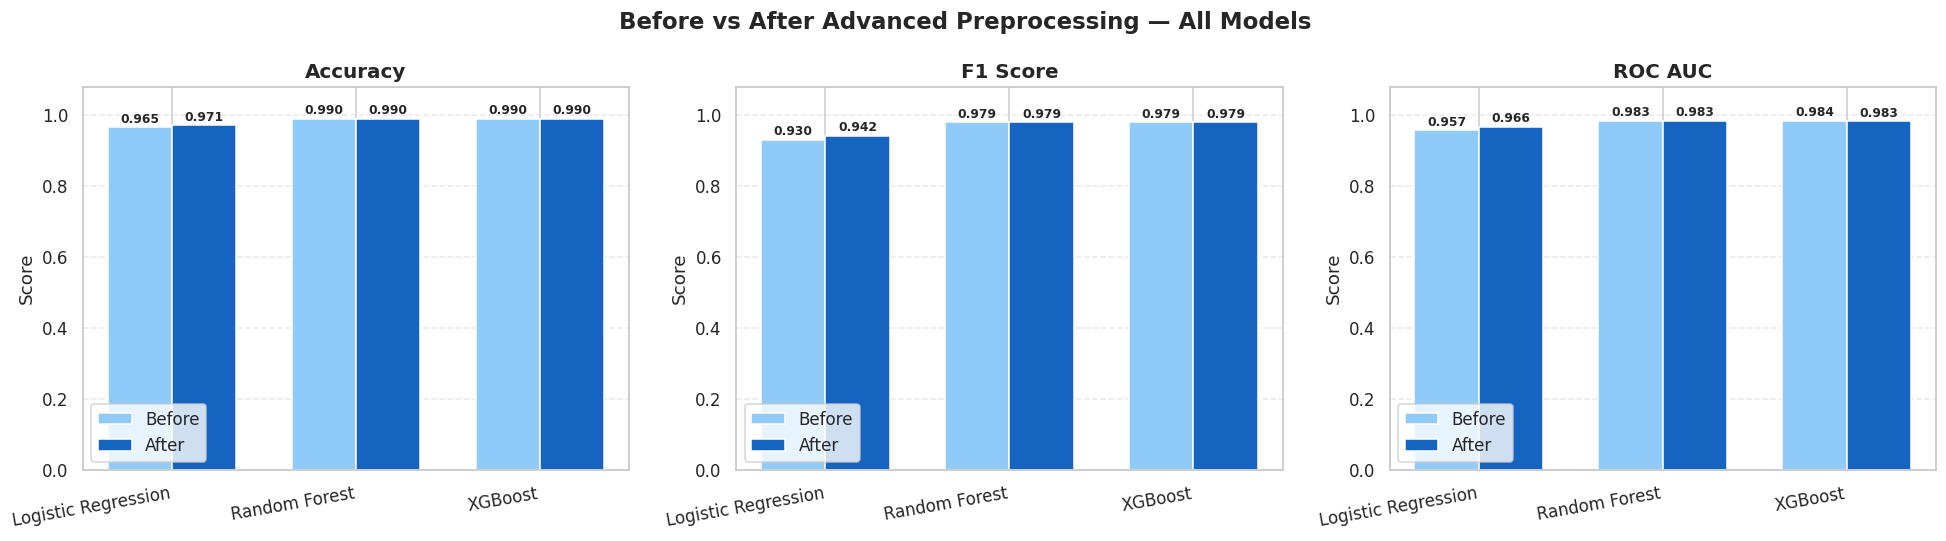

In [59]:
# ── Grouped bar chart: Before vs After ────────────────────────────────────
metrics_to_plot = ['Accuracy', 'F1 Score', 'ROC AUC']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

model_names = before_df.index.tolist()
x = np.arange(len(model_names))
width = 0.35

colors_before = '#90CAF9'
colors_after  = '#1565C0'

for ax, metric in zip(axes, metrics_to_plot):
    b_vals = before_df[metric].values
    a_vals = after_df[metric].values
    bars1 = ax.bar(x - width/2, b_vals, width, label='Before', color=colors_before, edgecolor='white')
    bars2 = ax.bar(x + width/2, a_vals, width, label='After',  color=colors_after,  edgecolor='white')
    ax.set_xticks(x)
    ax.set_xticklabels(model_names, rotation=10, ha='right')
    ax.set_ylim(0, 1.08)
    ax.set_title(metric, fontweight='bold', fontsize=13)
    ax.set_ylabel('Score')
    ax.legend()
    ax.grid(axis='y', alpha=0.4, linestyle='--')
    for bar in list(bars1) + list(bars2):
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.005, f'{h:.3f}',
                ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.suptitle('Before vs After Advanced Preprocessing — All Models', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

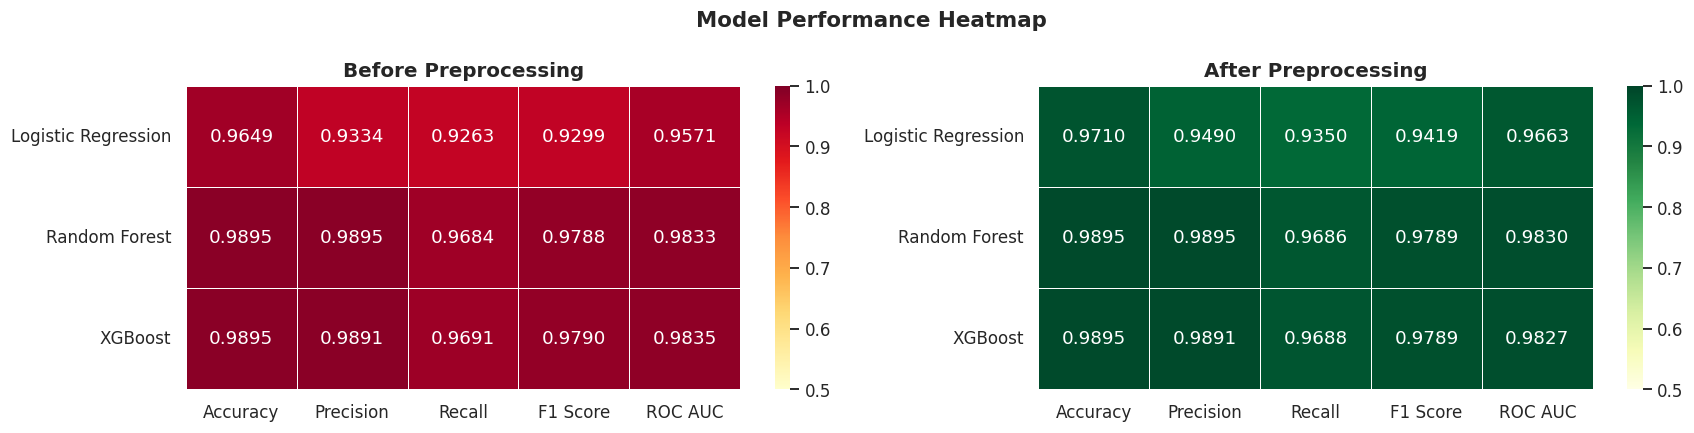

In [60]:
# ── Full metric heatmap — After preprocessing ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

sns.heatmap(before_df.astype(float), annot=True, fmt='.4f', cmap='YlOrRd',
            vmin=0.5, vmax=1.0, ax=axes[0], linewidths=0.5)
axes[0].set_title('Before Preprocessing', fontweight='bold', fontsize=13)

sns.heatmap(after_df.astype(float), annot=True, fmt='.4f', cmap='YlGn',
            vmin=0.5, vmax=1.0, ax=axes[1], linewidths=0.5)
axes[1].set_title('After Preprocessing', fontweight='bold', fontsize=13)

plt.suptitle('Model Performance Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## SECTION 7 — Deep Dive: Best Model Analysis

In [61]:
# ── Pick best model by F1 Score ───────────────────────────────────────────
best_model_name = after_df['F1 Score'].idxmax()
print(f'Best model by F1 Score: {best_model_name}')
print(after_df.loc[best_model_name])

Best model by F1 Score: Random Forest
Accuracy     0.9895
Precision    0.9895
Recall       0.9686
F1 Score     0.9789
ROC AUC      0.9830
Name: Random Forest, dtype: float64


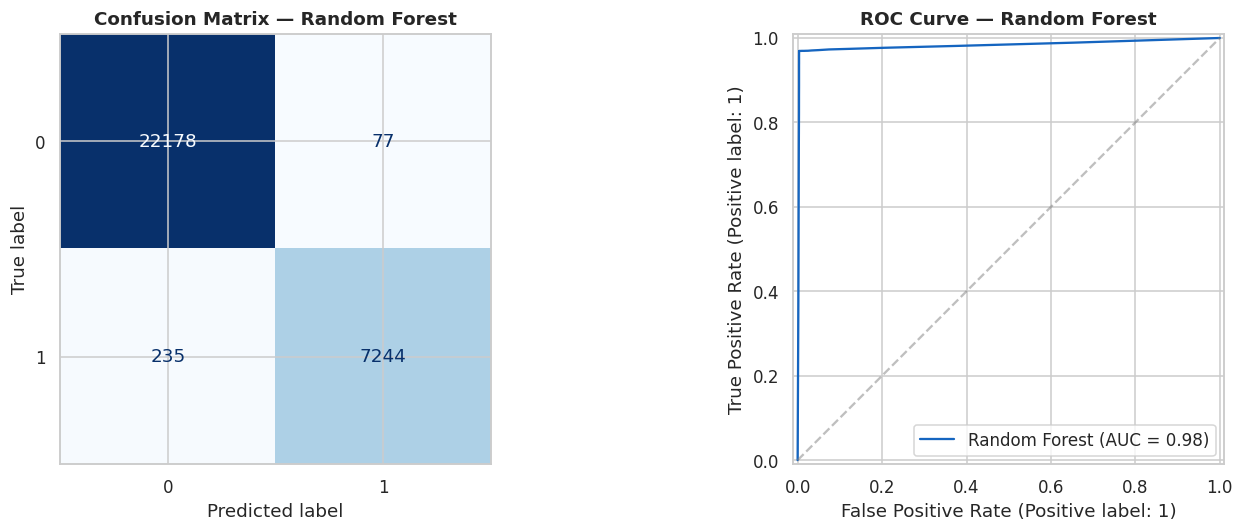


Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99     22255
           1       0.99      0.97      0.98      7479

    accuracy                           0.99     29734
   macro avg       0.99      0.98      0.99     29734
weighted avg       0.99      0.99      0.99     29734



In [62]:
# ── Confusion Matrix for best model ──────────────────────────────────────
# BUG FIX: Re-train fresh instance of best model
best_model = get_fresh_models()[best_model_name]
best_model.fit(X_train, y_train)
y_pred_best = best_model.predict(X_test)
y_prob_best = best_model.predict_proba(X_test)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title(f'Confusion Matrix — {best_model_name}', fontweight='bold')

# ROC Curve
RocCurveDisplay.from_predictions(y_test, y_prob_best, ax=axes[1],
                                  name=best_model_name, color='#1565C0')
axes[1].plot([0,1],[0,1],'--', color='gray', alpha=0.5)
axes[1].set_title(f'ROC Curve — {best_model_name}', fontweight='bold')

plt.tight_layout()
plt.show()

print('\nClassification Report:')
print(classification_report(y_test, y_pred_best))

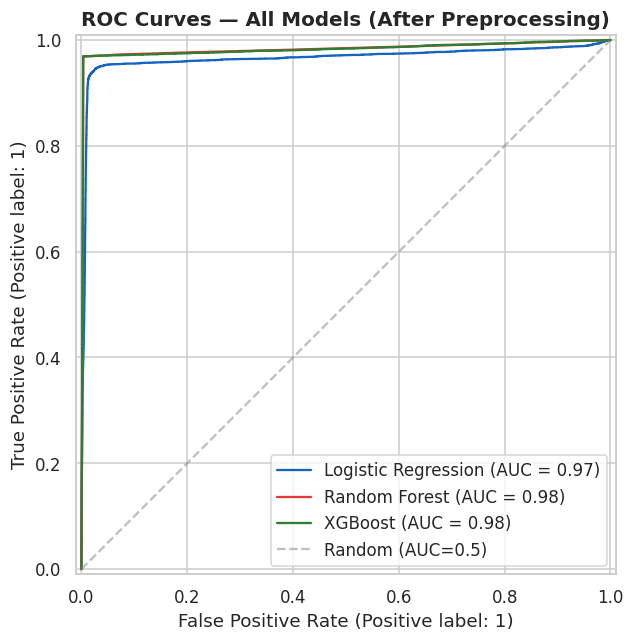

In [63]:
# ── ROC Curves — All 3 Models Overlaid ───────────────────────────────────
plt.figure(figsize=(9, 6))
colors = ['#1565C0', '#E53935', '#2E7D32']

for (name, model), color in zip(full_models.items(), colors):
    y_prob_m = model.predict_proba(X_test)[:, 1]
    RocCurveDisplay.from_predictions(y_test, y_prob_m, ax=plt.gca(),
                                      name=name, color=color)

plt.plot([0,1],[0,1],'--', color='gray', alpha=0.5, label='Random (AUC=0.5)')
plt.title('ROC Curves — All Models (After Preprocessing)', fontweight='bold', fontsize=13)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

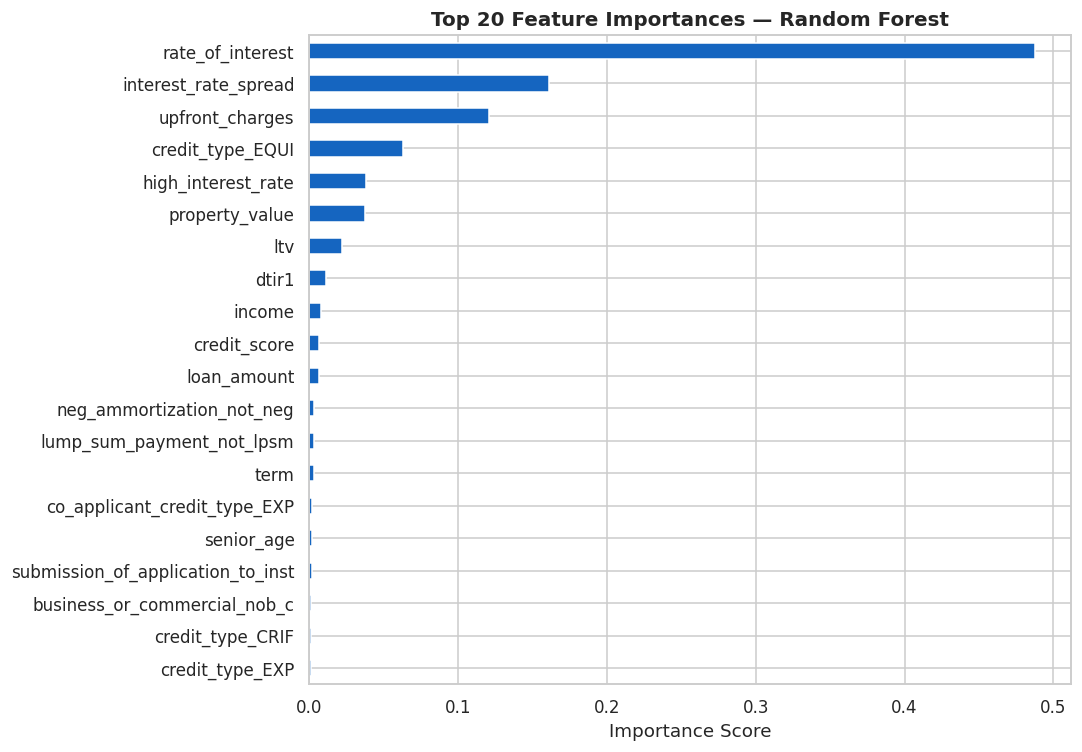


⚠️  Fairness-sensitive features in top 20 — bias audit recommended:
['senior_age']


In [64]:
# ── Feature Importance (Random Forest or XGBoost) ─────────────────────────
importance_model_name = 'Random Forest' if 'Random Forest' in full_models else 'XGBoost'
importance_model = full_models[importance_model_name]

if hasattr(importance_model, 'feature_importances_'):
    feat_imp = pd.Series(
        importance_model.feature_importances_,
        index=X_encoded.columns
    ).sort_values(ascending=False).head(20)

    plt.figure(figsize=(10, 7))
    feat_imp.plot(kind='barh', color='#1565C0', edgecolor='white')
    plt.gca().invert_yaxis()
    plt.title(f'Top 20 Feature Importances — {importance_model_name}', fontweight='bold', fontsize=13)
    plt.xlabel('Importance Score')
    plt.tight_layout()
    plt.show()

    # Check if fairness-sensitive features (gender, region) rank high
    fairness_features = [c for c in feat_imp.index if any(f in c.lower() for f in ['gender','region','age','loan_limit'])]
    if fairness_features:
        print('\n⚠️  Fairness-sensitive features in top 20 — bias audit recommended:')
        print([f for f in fairness_features])
    else:
        print('\n✅ Fairness-sensitive features are not dominant predictors')

---
## SECTION 8 — Fairness Audit (SDG 10)
> Computes Statistical Parity Difference and Disparate Impact Ratio across demographic groups.

In [65]:
# ── Fairness Audit ────────────────────────────────────────────────────────
# Re-attach fairness columns to test set for audit
test_idx = X_test_raw.index
df_test_fair = df_clean.loc[test_idx].copy()
df_test_fair['predicted'] = y_pred_best
df_test_fair['actual'] = y_test.values

fairness_audit_cols = [c for c in ['gender', 'region', 'loan_limit', 'loan_purpose', 'age']
                       if c in df_test_fair.columns]

fairness_results = []
for col in fairness_audit_cols:
    group_rates = df_test_fair.groupby(col)['predicted'].mean()
    if len(group_rates) >= 2:
        max_rate = group_rates.max()
        min_rate = group_rates.min()
        spd = round(max_rate - min_rate, 4)           # Statistical Parity Difference
        dir_ = round(min_rate / max_rate, 4) if max_rate > 0 else None  # Disparate Impact Ratio
        fairness_results.append({
            'Feature': col,
            'Max Approval Rate': f'{max_rate:.1%}',
            'Min Approval Rate': f'{min_rate:.1%}',
            'Stat. Parity Diff (SPD)': spd,
            'Disparate Impact Ratio (DIR)': dir_,
            'Biased?': '⚠️ YES' if (dir_ is not None and dir_ < 0.8) else '✅ OK'
        })

if fairness_results:
    fairness_df = pd.DataFrame(fairness_results)
    print('Fairness Audit Results (SPD ideal=0, DIR ideal=1.0, below 0.8 = discrimination):')
    display(fairness_df)
else:
    print('No fairness-sensitive columns found in test data — skipping audit')

Fairness Audit Results (SPD ideal=0, DIR ideal=1.0, below 0.8 = discrimination):


,Feature,Max Approval Rate,Min Approval Rate,Stat. Parity Diff (SPD),Disparate Impact Ratio (DIR),Biased?
0,gender,28.3%,19.4%,0.0892,0.6846,⚠️ YES
1,region,27.9%,23.0%,0.0490,0.8241,✅ OK
2,loan_limit,33.7%,24.0%,0.0976,0.7106,⚠️ YES
3,loan_purpose,33.5%,23.1%,0.1041,0.6893,⚠️ YES
4,age,35.1%,22.3%,0.1277,0.6362,⚠️ YES


---
## SECTION 9 — Final Summary

In [66]:
# ── Final Summary Table ───────────────────────────────────────────────────
print('=' * 65)
print('         EQUILOAN — FINAL MODEL COMPARISON SUMMARY')
print('=' * 65)
print('\n📊 BEFORE Advanced Preprocessing:')
print(before_df.to_string())
print('\n📊 AFTER Advanced Preprocessing (IQR clipping + StandardScaler):')
print(after_df.to_string())
print('\n📈 Improvement (After − Before):')
delta = after_df - before_df
print(delta.to_string())
print('\n' + '=' * 65)
print(f'🏆 Best model (by F1): {best_model_name}')
print(f"   Accuracy : {after_df.loc[best_model_name, 'Accuracy']:.4f}")
print(f"   F1 Score : {after_df.loc[best_model_name, 'F1 Score']:.4f}")
print(f"   ROC AUC  : {after_df.loc[best_model_name, 'ROC AUC']:.4f}")
print('=' * 65)
print()

         EQUILOAN — FINAL MODEL COMPARISON SUMMARY

📊 BEFORE Advanced Preprocessing:
                     Accuracy  Precision  Recall  F1 Score  ROC AUC
Logistic Regression    0.9649     0.9334  0.9263    0.9299   0.9571
Random Forest          0.9895     0.9895  0.9684    0.9788   0.9833
XGBoost                0.9895     0.9891  0.9691    0.9790   0.9835

📊 AFTER Advanced Preprocessing (IQR clipping + StandardScaler):
                     Accuracy  Precision  Recall  F1 Score  ROC AUC
Logistic Regression    0.9710     0.9490  0.9350    0.9419   0.9663
Random Forest          0.9895     0.9895  0.9686    0.9789   0.9830
XGBoost                0.9895     0.9891  0.9688    0.9789   0.9827

📈 Improvement (After − Before):
                     Accuracy  Precision  Recall  F1 Score  ROC AUC
Logistic Regression    0.0061     0.0156  0.0087    0.0120   0.0092
Random Forest          0.0000     0.0000  0.0002    0.0001  -0.0003
XGBoost                0.0000     0.0000 -0.0003   -0.0001  -0.0008



In [67]:
# ── Save results to CSV ───────────────────────────────────────────────────
before_df.to_csv('Before_Preprocessing_Results.csv')
after_df.to_csv('After_Preprocessing_Results.csv')
comparison.to_csv('Before_After_Comparison.csv')
print('✅ Results saved:')
print('   Before_Preprocessing_Results.csv')
print('   After_Preprocessing_Results.csv')
print('   Before_After_Comparison.csv')

✅ Results saved:
   Before_Preprocessing_Results.csv
   After_Preprocessing_Results.csv
   Before_After_Comparison.csv
